In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
# Gemeinsamen Merge repo-relativ laden
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Repository-Wurzel mit .git wurde nicht gefunden.")


MERGED_FILE = (
    find_repo_root()
    / "dataset"
    / "cleaned"
    / "merged"
    / "all_sources_attacks_merged_analysis_ready.csv"
)
if not MERGED_FILE.exists():
    raise FileNotFoundError(
        f"Merge-Datei fehlt: {MERGED_FILE}\n"
        "Bitte zuerst dataset/raw/Merge all files.ipynb vollständig ausführen."
    )

combined = pd.read_csv(MERGED_FILE, low_memory=False)
print("Loaded file:", MERGED_FILE)
print("Shape:", combined.shape)
display(combined.head())


Loaded file: d:\HS Hof files all sem\HS Hof files Sem 7\Data Anlayse & Mining\Repo\dataset\cleaned\merged\all_sources_attacks_merged_analysis_ready.csv
Shape: (4066498, 36)


,attack_id,patient_id,source_group,headache,migraine,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,attack_datetime,...,attack_date,year,month,month_name,weekday_num,weekday_name,season,week_start,migraine_group,age_group
0,117,72741515,AppOnly,True,False,False,False,True,False,2020-06-08,...,2020-06-08,2020,6,Juni,0,Montag,Sommer,2020-06-08,Nicht-Migraene,30-44
1,118,72741515,AppOnly,True,True,False,False,True,False,2020-06-09,...,2020-06-09,2020,6,Juni,1,Dienstag,Sommer,2020-06-08,Migraene,30-44
2,127,44203359,AppOnly,True,True,False,True,True,False,2020-06-19,...,2020-06-19,2020,6,Juni,4,Freitag,Sommer,2020-06-15,Migraene,45-59
3,128,44203359,AppOnly,True,True,False,True,True,False,2020-06-20,...,2020-06-20,2020,6,Juni,5,Samstag,Sommer,2020-06-15,Migraene,45-59
4,129,44203359,AppOnly,True,True,False,True,True,False,2020-06-21,...,2020-06-21,2020,6,Juni,6,Sonntag,Sommer,2020-06-15,Migraene,45-59


In [3]:
fq5_required_columns = [
    "patient_id",
    "gender",
    "age_reg",
    "age_group",
    "attack_datetime",
    "migraine",
    "headache",
    "comment_menstruation",
    "first_app_entry_date",
    "last_app_entry_date"
]

missing_columns = [
    col for col in fq5_required_columns
    if col not in combined.columns
]

if len(missing_columns) == 0:
    print("All required FQ5 columns are available.")
else:
    print("Missing columns:")
    print(missing_columns)

All required FQ5 columns are available.


In [4]:
df_fq5 = combined.copy()

df_fq5["attack_datetime"] = pd.to_datetime(
    df_fq5["attack_datetime"],
    errors="coerce"
)

df_fq5["first_app_entry_date"] = pd.to_datetime(
    df_fq5["first_app_entry_date"],
    errors="coerce"
)

df_fq5["last_app_entry_date"] = pd.to_datetime(
    df_fq5["last_app_entry_date"],
    errors="coerce"
)

df_fq5["age_reg"] = pd.to_numeric(
    df_fq5["age_reg"],
    errors="coerce"
)

df_fq5["patient_id"] = df_fq5["patient_id"].astype(str).str.strip()

if "attack_id" in df_fq5.columns:
    df_fq5["attack_id"] = df_fq5["attack_id"].astype(str).str.strip()

In [5]:
df_fq5 = df_fq5[
    (df_fq5["age_reg"] >= 18)
    & (df_fq5["attack_datetime"].notna())
    & (df_fq5["patient_id"].notna())
].copy()

print("FQ5 dataset shape after basic filtering:", df_fq5.shape)
print("Unique patients:", df_fq5["patient_id"].nunique())
print("Total attacks:", len(df_fq5))

FQ5 dataset shape after basic filtering: (3956188, 36)
Unique patients: 61622
Total attacks: 3956188


In [6]:
def clean_gender(value):
    if pd.isna(value):
        return "missing"

    value = str(value).strip().lower()

    if value in ["female", "weiblich", "frau", "f"]:
        return "female"
    elif value in ["male", "männlich", "maennlich", "mann", "m"]:
        return "male"
    elif value in ["divers", "diverse", "other", "non-binary", "nonbinary"]:
        return "diverse"
    else:
        return "other_or_unclear"


df_fq5["gender_clean"] = df_fq5["gender"].apply(clean_gender)

print("Gender values after cleaning:")
display(
    df_fq5["gender_clean"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "gender_clean", "gender_clean": "count"})
)

Gender values after cleaning:


,count,count
0,female,3242507
1,male,691681
2,diverse,22000


In [7]:
def clean_boolean_flag(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, bool):
        return value

    value_str = str(value).strip().lower()

    true_values = ["true", "1", "yes", "ja", "y"]
    false_values = ["false", "0", "no", "nein", "n"]

    if value_str in true_values:
        return True
    elif value_str in false_values:
        return False
    else:
        return np.nan


df_fq5["migraine_flag"] = df_fq5["migraine"].apply(clean_boolean_flag)
df_fq5["headache_flag"] = df_fq5["headache"].apply(clean_boolean_flag)
df_fq5["menstruation_flag"] = df_fq5["comment_menstruation"].apply(clean_boolean_flag)
def menstruation_status(value):
    if pd.isna(value):
        return "missing"
    elif value is True:
        return "true"
    elif value is False:
        return "false"
    else:
        return "missing"


df_fq5["menstruation_status"] = df_fq5["menstruation_flag"].apply(menstruation_status)

print("Migraine flag distribution:")
display(df_fq5["migraine_flag"].value_counts(dropna=False))

print("Headache flag distribution:")
display(df_fq5["headache_flag"].value_counts(dropna=False))

print("Menstruation status distribution:")
display(df_fq5["menstruation_status"].value_counts(dropna=False))

Migraine flag distribution:


migraine_flag
False    2358774
True     1597414
Name: count, dtype: int64

Headache flag distribution:


headache_flag
True    3956188
Name: count, dtype: int64

Menstruation status distribution:


menstruation_status
missing    3737546
false       139357
true         79285
Name: count, dtype: int64

In [8]:
gender_overview = (
    df_fq5
    .groupby("gender_clean", observed=True)
    .agg(
        attacks=("patient_id", "count"),
        unique_patients=("patient_id", "nunique"),
        migraine_attacks=("migraine_flag", lambda x: (x == True).sum()),
        headache_attacks=("headache_flag", lambda x: (x == True).sum())
    )
    .reset_index()
)

gender_overview["migraine_attack_percentage"] = (
    gender_overview["migraine_attacks"]
    / gender_overview["attacks"]
    * 100
).round(2)

display(gender_overview)

,gender_clean,attacks,unique_patients,migraine_attacks,headache_attacks,migraine_attack_percentage
0,diverse,22000,408,7969,22000,36.22
1,female,3242507,50041,1356816,3242507,41.84
2,male,691681,11173,232629,691681,33.63


In [9]:
menstruation_overview_all = (
    df_fq5["menstruation_status"]
    .value_counts(dropna=False)
    .reset_index()
)

menstruation_overview_all.columns = [
    "menstruation_status",
    "attack_count"
]

menstruation_overview_all["attack_percentage"] = (
    menstruation_overview_all["attack_count"]
    / menstruation_overview_all["attack_count"].sum()
    * 100
).round(2)

print("Menstruation status across all attacks:")
display(menstruation_overview_all)
female_attacks = df_fq5[df_fq5["gender_clean"] == "female"].copy()

menstruation_overview_female = (
    female_attacks["menstruation_status"]
    .value_counts(dropna=False)
    .reset_index()
)

menstruation_overview_female.columns = [
    "menstruation_status",
    "female_attack_count"
]

menstruation_overview_female["female_attack_percentage"] = (
    menstruation_overview_female["female_attack_count"]
    / menstruation_overview_female["female_attack_count"].sum()
    * 100
).round(2)

print("Menstruation status among female attacks:")
display(menstruation_overview_female)


Menstruation status across all attacks:


,menstruation_status,attack_count,attack_percentage
0,missing,3737546,94.47
1,false,139357,3.52
2,true,79285,2.00


Menstruation status among female attacks:


,menstruation_status,female_attack_count,female_attack_percentage
0,missing,3023865,93.26
1,false,139357,4.30
2,true,79285,2.45


In [10]:
female_patient_menstruation_marker = (
    female_attacks
    .groupby("patient_id")
    .agg(
        total_attacks=("patient_id", "count"),
        menstruation_true_attacks=("menstruation_status", lambda x: (x == "true").sum()),
        menstruation_false_attacks=("menstruation_status", lambda x: (x == "false").sum()),
        menstruation_missing_attacks=("menstruation_status", lambda x: (x == "missing").sum())
    )
    .reset_index()
)

female_patient_menstruation_marker["has_menstruation_marker"] = (
    female_patient_menstruation_marker["menstruation_true_attacks"] > 0
)

women_with_marker = female_patient_menstruation_marker["has_menstruation_marker"].sum()
total_women = female_patient_menstruation_marker["patient_id"].nunique()

print("Total female patients:", total_women)
print("Female patients with at least one menstruation-marked attack:", women_with_marker)
print(
    "Percentage:",
    round(women_with_marker / total_women * 100, 2),
    "%"
)

display(female_patient_menstruation_marker.head())

Total female patients: 50041
Female patients with at least one menstruation-marked attack: 8864
Percentage: 17.71 %


,patient_id,total_attacks,menstruation_true_attacks,menstruation_false_attacks,menstruation_missing_attacks,has_menstruation_marker
0,10005187,9,0,0,9,False
1,10005818,22,0,0,22,False
2,10007520,122,0,11,111,False
3,10010442,7,0,0,7,False
4,10011017,243,0,0,243,False


In [11]:
missing_overview = pd.DataFrame({
    "column": fq5_required_columns + [
        "gender_clean",
        "migraine_flag",
        "headache_flag",
        "menstruation_status"
    ],
    "missing_count": [
        df_fq5[col].isna().sum() if col in df_fq5.columns else np.nan
        for col in fq5_required_columns + [
            "gender_clean",
            "migraine_flag",
            "headache_flag",
            "menstruation_status"
        ]
    ],
    "missing_percentage": [
        round(df_fq5[col].isna().mean() * 100, 2) if col in df_fq5.columns else np.nan
        for col in fq5_required_columns + [
            "gender_clean",
            "migraine_flag",
            "headache_flag",
            "menstruation_status"
        ]
    ]
})

display(missing_overview)

,column,missing_count,missing_percentage
0,patient_id,0,0.00
1,gender,0,0.00
2,age_reg,0,0.00
3,age_group,0,0.00
4,attack_datetime,0,0.00
5,migraine,0,0.00
6,headache,0,0.00
7,comment_menstruation,3737546,94.47
8,first_app_entry_date,0,0.00
9,last_app_entry_date,0,0.00


In [12]:
def most_common_value(series):
    series = series.dropna()
    if len(series) == 0:
        return np.nan
    return series.mode().iloc[0]


df_fq5["attack_date"] = df_fq5["attack_datetime"].dt.date
df_fq5["attack_date"] = pd.to_datetime(df_fq5["attack_date"])

df_fq5["migraine_true_int"] = (df_fq5["migraine_flag"] == True).astype(int)
df_fq5["headache_true_int"] = (df_fq5["headache_flag"] == True).astype(int)
df_fq5["menstruation_true_int"] = (df_fq5["menstruation_status"] == "true").astype(int)
df_fq5["menstruation_false_int"] = (df_fq5["menstruation_status"] == "false").astype(int)
df_fq5["menstruation_missing_int"] = (df_fq5["menstruation_status"] == "missing").astype(int)
patient_observation = (
    df_fq5
    .groupby("patient_id")
    .agg(
        gender=("gender_clean", most_common_value),
        age_reg=("age_reg", "median"),
        age_group=("age_group", most_common_value),

        first_app_entry_date=("first_app_entry_date", "min"),
        last_app_entry_date=("last_app_entry_date", "max"),

        first_attack_date=("attack_date", "min"),
        last_attack_date=("attack_date", "max"),

        total_attacks=("patient_id", "count"),
        migraine_attacks=("migraine_true_int", "sum"),
        headache_attacks=("headache_true_int", "sum"),

        menstruation_true_attacks=("menstruation_true_int", "sum"),
        menstruation_false_attacks=("menstruation_false_int", "sum"),
        menstruation_missing_attacks=("menstruation_missing_int", "sum")
    )
    .reset_index()
)

patient_observation["app_observation_days"] = (
    patient_observation["last_app_entry_date"]
    - patient_observation["first_app_entry_date"]
).dt.days + 1

patient_observation["attack_observation_days"] = (
    patient_observation["last_attack_date"]
    - patient_observation["first_attack_date"]
).dt.days + 1

patient_observation["observation_days_for_rate"] = (
    patient_observation["app_observation_days"]
    .combine_first(patient_observation["attack_observation_days"])
)

patient_observation.loc[
    patient_observation["observation_days_for_rate"] < 1,
    "observation_days_for_rate"
] = 1

patient_observation["attacks_per_30_days"] = (
    patient_observation["total_attacks"]
    / patient_observation["observation_days_for_rate"]
    * 30
)

patient_observation["migraine_attacks_per_30_days"] = (
    patient_observation["migraine_attacks"]
    / patient_observation["observation_days_for_rate"]
    * 30
)

patient_observation["migraine_share"] = (
    patient_observation["migraine_attacks"]
    / patient_observation["total_attacks"]
    * 100
)

patient_observation["has_menstruation_marker"] = (
    patient_observation["menstruation_true_attacks"] > 0
)

patient_observation["menstruation_marker_share"] = (
    patient_observation["menstruation_true_attacks"]
    / patient_observation["total_attacks"]
    * 100
)

display(patient_observation.head())

,patient_id,gender,age_reg,age_group,first_app_entry_date,last_app_entry_date,first_attack_date,last_attack_date,total_attacks,migraine_attacks,...,menstruation_false_attacks,menstruation_missing_attacks,app_observation_days,attack_observation_days,observation_days_for_rate,attacks_per_30_days,migraine_attacks_per_30_days,migraine_share,has_menstruation_marker,menstruation_marker_share
0,10005187,female,21.0,18-29,2024-04-22,2024-05-19,2024-04-27,2024-05-19,9,0,...,0,9,28,23,28,9.642857,0.000000,0.000000,False,0.0
1,10005708,male,29.0,18-29,2021-09-08,2021-11-22,2021-09-14,2021-11-19,10,5,...,0,10,76,67,76,3.947368,1.973684,50.000000,False,0.0
2,10005818,female,57.0,45-59,2025-03-08,2025-12-02,2025-03-08,2025-12-02,22,16,...,0,22,270,270,270,2.444444,1.777778,72.727273,False,0.0
3,10007520,female,61.0,60+,2023-06-21,2024-11-18,2023-06-21,2024-10-13,122,10,...,11,111,517,481,517,7.079304,0.580271,8.196721,False,0.0
4,10009199,male,41.0,30-44,2025-09-28,2025-11-18,2025-09-28,2025-11-16,24,2,...,0,24,52,50,52,13.846154,1.153846,8.333333,False,0.0


In [13]:
print("Observation days per patient:")
display(patient_observation["observation_days_for_rate"].describe())

print("Total attacks per patient:")
display(patient_observation["total_attacks"].describe())

print("Migraine attacks per patient:")
display(patient_observation["migraine_attacks"].describe())

print("Attacks per 30 days:")
display(patient_observation["attacks_per_30_days"].describe())

print("Migraine attacks per 30 days:")
display(patient_observation["migraine_attacks_per_30_days"].describe())

Observation days per patient:


count    61622.000000
mean       271.306644
std        354.167590
min          1.000000
25%         29.000000
50%        123.000000
75%        372.000000
max       2080.000000
Name: observation_days_for_rate, dtype: float64

Total attacks per patient:


count    61622.000000
mean        64.200902
std        115.512411
min          1.000000
25%          7.000000
50%         23.000000
75%         71.000000
max       1974.000000
Name: total_attacks, dtype: float64

Migraine attacks per patient:


count    61622.000000
mean        25.922787
std         63.910171
min          0.000000
25%          1.000000
50%          5.000000
75%         21.000000
max       1820.000000
Name: migraine_attacks, dtype: float64

Attacks per 30 days:


count    61622.000000
mean        10.467469
std          8.703408
min          0.028302
25%          4.090909
50%          7.471481
75%         14.000000
max         30.000000
Name: attacks_per_30_days, dtype: float64

Migraine attacks per 30 days:


count    61622.000000
mean         3.519589
std          5.674302
min          0.000000
25%          0.218978
50%          1.544118
75%          4.201153
max         30.000000
Name: migraine_attacks_per_30_days, dtype: float64

In [14]:
female_patient_observation = patient_observation[
    patient_observation["gender"] == "female"
].copy()

female_patient_summary = pd.DataFrame({
    "metric": [
        "female_patients",
        "female_patients_with_menstruation_marker",
        "female_patients_without_menstruation_marker",
        "percentage_with_menstruation_marker"
    ],
    "value": [
        female_patient_observation["patient_id"].nunique(),
        female_patient_observation["has_menstruation_marker"].sum(),
        (~female_patient_observation["has_menstruation_marker"]).sum(),
        round(
            female_patient_observation["has_menstruation_marker"].mean() * 100,
            2
        )
    ]
})

display(female_patient_summary)

,metric,value
0,female_patients,50041.00
1,female_patients_with_menstruation_marker,8864.00
2,female_patients_without_menstruation_marker,41177.00
3,percentage_with_menstruation_marker,17.71


In [15]:
# ------------------------------------------------------------
# Step 5.2: Women-only menstruation marker overview
# ------------------------------------------------------------

female_attacks = df_fq5[df_fq5["gender_clean"] == "female"].copy()

total_female_attacks = len(female_attacks)
female_migraine_attacks = (female_attacks["migraine_flag"] == True).sum()

female_menstruation_true_attacks = (
    female_attacks["menstruation_status"] == "true"
).sum()

female_menstruation_false_attacks = (
    female_attacks["menstruation_status"] == "false"
).sum()

female_menstruation_missing_attacks = (
    female_attacks["menstruation_status"] == "missing"
).sum()

total_female_patients = female_attacks["patient_id"].nunique()

female_patient_observation = patient_observation[
    patient_observation["gender"] == "female"
].copy()

female_patients_with_marker = (
    female_patient_observation["has_menstruation_marker"] == True
).sum()

female_patients_without_marker = (
    female_patient_observation["has_menstruation_marker"] == False
).sum()

percentage_female_patients_with_marker = (
    female_patients_with_marker / total_female_patients * 100
)

fq5_2_summary = pd.DataFrame({
    "metric": [
        "total_female_attacks",
        "female_migraine_attacks",
        "female_migraine_attack_percentage",
        "female_attacks_menstruation_true",
        "female_attacks_menstruation_false",
        "female_attacks_menstruation_missing",
        "female_attacks_menstruation_true_percentage",
        "female_attacks_menstruation_false_percentage",
        "female_attacks_menstruation_missing_percentage",
        "total_female_patients",
        "female_patients_with_menstruation_marker",
        "female_patients_without_menstruation_marker",
        "percentage_female_patients_with_menstruation_marker"
    ],
    "value": [
        total_female_attacks,
        female_migraine_attacks,
        round(female_migraine_attacks / total_female_attacks * 100, 2),
        female_menstruation_true_attacks,
        female_menstruation_false_attacks,
        female_menstruation_missing_attacks,
        round(female_menstruation_true_attacks / total_female_attacks * 100, 2),
        round(female_menstruation_false_attacks / total_female_attacks * 100, 2),
        round(female_menstruation_missing_attacks / total_female_attacks * 100, 2),
        total_female_patients,
        female_patients_with_marker,
        female_patients_without_marker,
        round(percentage_female_patients_with_marker, 2)
    ]
})

display(fq5_2_summary)

,metric,value
0,total_female_attacks,3242507.00
1,female_migraine_attacks,1356816.00
2,female_migraine_attack_percentage,41.84
3,female_attacks_menstruation_true,79285.00
4,female_attacks_menstruation_false,139357.00
5,female_attacks_menstruation_missing,3023865.00
6,female_attacks_menstruation_true_percentage,2.45
7,female_attacks_menstruation_false_percentage,4.30
8,female_attacks_menstruation_missing_percentage,93.26
9,total_female_patients,50041.00


In [16]:
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# Step 5.3: Menstruation marker vs migraine
# ------------------------------------------------------------
# Research question:
# Among female attacks with explicit menstruation information,
# are menstruation-marked attacks more often migraine attacks?

female_attacks = df_fq5[df_fq5["gender_clean"] == "female"].copy()

female_menstruation_explicit = female_attacks[
    female_attacks["menstruation_status"].isin(["true", "false"])
    & female_attacks["migraine_flag"].notna()
].copy()

print("Female attacks total:", len(female_attacks))
print("Female attacks with explicit menstruation true/false and valid migraine flag:", len(female_menstruation_explicit))

display(
    female_menstruation_explicit[
        ["patient_id", "attack_datetime", "menstruation_status", "migraine_flag"]
    ].head()
)

Female attacks total: 3242507
Female attacks with explicit menstruation true/false and valid migraine flag: 218642


,patient_id,attack_datetime,menstruation_status,migraine_flag
35568,64067984,2021-07-06,true,True
35695,59336874,2021-07-06,true,False
35820,39143052,2021-07-07,false,True
35949,51253493,2021-07-06,false,False
35950,51253493,2021-07-07,false,True


In [17]:
contingency_table = pd.crosstab(
    female_menstruation_explicit["menstruation_status"],
    female_menstruation_explicit["migraine_flag"]
)

# Ensure stable row/column order
contingency_table = contingency_table.reindex(
    index=["false", "true"],
    columns=[False, True],
    fill_value=0
)

contingency_table.columns = ["migraine_false", "migraine_true"]

display(contingency_table)

,migraine_false,migraine_true
menstruation_status,,
false,80755,58602
true,44135,35150


In [18]:
menstruation_migraine_percentages = contingency_table.copy()

menstruation_migraine_percentages["total_attacks"] = (
    menstruation_migraine_percentages["migraine_false"]
    + menstruation_migraine_percentages["migraine_true"]
)

menstruation_migraine_percentages["migraine_percentage"] = (
    menstruation_migraine_percentages["migraine_true"]
    / menstruation_migraine_percentages["total_attacks"]
    * 100
).round(2)

menstruation_migraine_percentages["non_migraine_percentage"] = (
    menstruation_migraine_percentages["migraine_false"]
    / menstruation_migraine_percentages["total_attacks"]
    * 100
).round(2)

display(menstruation_migraine_percentages)

,migraine_false,migraine_true,total_attacks,migraine_percentage,non_migraine_percentage
menstruation_status,,,,,
false,80755,58602,139357,42.05,57.95
true,44135,35150,79285,44.33,55.67


In [19]:
migraine_percentage_false = menstruation_migraine_percentages.loc[
    "false",
    "migraine_percentage"
]

migraine_percentage_true = menstruation_migraine_percentages.loc[
    "true",
    "migraine_percentage"
]

migraine_percentage_difference = migraine_percentage_true - migraine_percentage_false

print("Migraine percentage when menstruation_status == false:", migraine_percentage_false, "%")
print("Migraine percentage when menstruation_status == true:", migraine_percentage_true, "%")
print("Difference true - false:", round(migraine_percentage_difference, 2), "percentage points")

Migraine percentage when menstruation_status == false: 42.05 %
Migraine percentage when menstruation_status == true: 44.33 %
Difference true - false: 2.28 percentage points


In [20]:
# ------------------------------------------------------------
# Step 5.3 Cell 6: Chi-square test with hypotheses and decision
# ------------------------------------------------------------

ALPHA = 0.05

observed = contingency_table[["migraine_false", "migraine_true"]].values

print("Chi-square test: menstruation marker vs migraine among female attacks")
print("=" * 75)

print("Significance level alpha:", ALPHA)
print("Confidence level:", int((1 - ALPHA) * 100), "%")

print("\nHypotheses:")
print("H0: Menstruation marker and migraine status are independent.")
print("    This means the migraine proportion is the same for menstruation_status == true and false.")
print("H1: Menstruation marker and migraine status are associated.")
print("    This means the migraine proportion differs between menstruation_status == true and false.")

chi2_statistic, p_value, dof, expected = chi2_contingency(
    observed,
    correction=False
)

expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nObserved frequencies:")
display(contingency_table)

print("\nExpected frequencies under H0:")
display(expected_table)

print("\nTest result:")
print("Chi2 statistic:", chi2_statistic)
print("Degrees of freedom:", dof)
print("Raw p-value:", p_value)
print("Raw p-value scientific:", f"{p_value:.3e}")

print("\nDecision:")
if p_value < ALPHA:
    print("p < alpha → reject H0.")
    print("Interpretation: Menstruation marker and migraine status are statistically associated.")
else:
    print("p >= alpha → do not reject H0.")
    print("Interpretation: No statistically significant association was found.")

Chi-square test: menstruation marker vs migraine among female attacks
Significance level alpha: 0.05
Confidence level: 95 %

Hypotheses:
H0: Menstruation marker and migraine status are independent.
    This means the migraine proportion is the same for menstruation_status == true and false.
H1: Menstruation marker and migraine status are associated.
    This means the migraine proportion differs between menstruation_status == true and false.

Observed frequencies:


,migraine_false,migraine_true
menstruation_status,,
false,80755,58602
true,44135,35150



Expected frequencies under H0:


,migraine_false,migraine_true
menstruation_status,,
false,79601.795309,59755.204691
true,45288.204691,33996.795309



Test result:
Chi2 statistic: 107.44483633607706
Degrees of freedom: 1
Raw p-value: 3.5566857516402387e-25
Raw p-value scientific: 3.557e-25

Decision:
p < alpha → reject H0.
Interpretation: Menstruation marker and migraine status are statistically associated.


In [21]:
def cramers_v_from_chi2(chi2, n, rows, cols):
    min_dimension = min(rows - 1, cols - 1)

    if min_dimension == 0:
        return np.nan

    return np.sqrt(chi2 / (n * min_dimension))


n_total = observed.sum()
rows, cols = observed.shape

cramers_v = cramers_v_from_chi2(
    chi2=chi2_statistic,
    n=n_total,
    rows=rows,
    cols=cols
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.022167972736976165


In [22]:
def interpret_cramers_v(v):
    if pd.isna(v):
        return "not interpretable"
    elif v < 0.1:
        return "very small / negligible"
    elif v < 0.3:
        return "small"
    elif v < 0.5:
        return "medium"
    else:
        return "large"


cramers_v_interpretation = interpret_cramers_v(cramers_v)

print("Cramer's V interpretation:", cramers_v_interpretation)

Cramer's V interpretation: very small / negligible


In [23]:
# ------------------------------------------------------------
# Step 5.3 extra: Contribution analysis for Chi-square test
# ------------------------------------------------------------
# Goal:
# Find which cells are responsible for the rejected H0.
#
# Chi-square contribution per cell:
# (observed - expected)^2 / expected

observed_table = contingency_table[["migraine_false", "migraine_true"]].copy()

expected_table = pd.DataFrame(
    expected,
    index=observed_table.index,
    columns=observed_table.columns
)

chi_square_contribution = (
    (observed_table - expected_table) ** 2
    / expected_table
)

chi_square_contribution_percent = (
    chi_square_contribution
    / chi_square_contribution.values.sum()
    * 100
)

pearson_residuals = (
    (observed_table - expected_table)
    / np.sqrt(expected_table)
)

print("Observed frequencies:")
display(observed_table)

print("Expected frequencies under H0:")
display(expected_table)

print("Cell contributions to Chi-square:")
display(chi_square_contribution.round(3))

print("Cell contribution percentages:")
display(chi_square_contribution_percent.round(2))

print("Pearson residuals:")
display(pearson_residuals.round(3))

Observed frequencies:


,migraine_false,migraine_true
menstruation_status,,
false,80755,58602
true,44135,35150


Expected frequencies under H0:


,migraine_false,migraine_true
menstruation_status,,
false,79601.795309,59755.204691
true,45288.204691,33996.795309


Cell contributions to Chi-square:


,migraine_false,migraine_true
menstruation_status,,
false,16.707,22.255
true,29.365,39.118


Cell contribution percentages:


,migraine_false,migraine_true
menstruation_status,,
false,15.55,20.71
true,27.33,36.41


Pearson residuals:


,migraine_false,migraine_true
menstruation_status,,
false,4.087,-4.718
true,-5.419,6.254


In [24]:
fq5_3_result = pd.DataFrame({
    "analysis": ["menstruation_marker_vs_migraine_female_attacks"],
    "population": ["female attacks with explicit menstruation true/false"],
    "test": ["Chi-square test"],
    "chi2_statistic": [chi2_statistic],
    "df": [dof],
    "p_raw": [p_value],
    "p_raw_scientific": [f"{p_value:.3e}"],
    "cramers_v": [cramers_v],
    "effect_size_interpretation": [cramers_v_interpretation],
    "migraine_percentage_menstruation_false": [migraine_percentage_false],
    "migraine_percentage_menstruation_true": [migraine_percentage_true],
    "difference_percentage_points_true_minus_false": [
        round(migraine_percentage_difference, 2)
    ],
    "n_attacks_used": [n_total]
})

fq5_3_result["chi2_statistic"] = fq5_3_result["chi2_statistic"].round(3)
fq5_3_result["cramers_v"] = fq5_3_result["cramers_v"].round(6)

display(fq5_3_result)

,analysis,population,test,chi2_statistic,df,p_raw,p_raw_scientific,cramers_v,effect_size_interpretation,migraine_percentage_menstruation_false,migraine_percentage_menstruation_true,difference_percentage_points_true_minus_false,n_attacks_used
0,menstruation_marker_vs_migraine_female_attacks,female attacks with explicit menstruation true...,Chi-square test,107.445,1,3.556686e-25,3.557e-25,0.022168,very small / negligible,42.05,44.33,2.28,218642


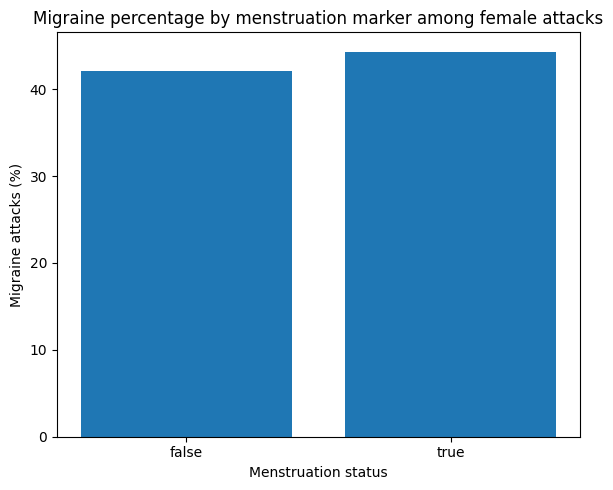

In [25]:
plot_df = menstruation_migraine_percentages.reset_index().copy()

plt.figure(figsize=(6, 5))

plt.bar(
    plot_df["menstruation_status"],
    plot_df["migraine_percentage"]
)

plt.xlabel("Menstruation status")
plt.ylabel("Migraine attacks (%)")
plt.title("Migraine percentage by menstruation marker among female attacks")

plt.tight_layout()
plt.show()

In [26]:
# ------------------------------------------------------------
# Step 5.4: Patient-level attack burden in women with/without menstruation marker
# ------------------------------------------------------------

female_burden_analysis = patient_observation[
    patient_observation["gender"] == "female"
].copy()

female_burden_analysis["menstruation_marker_group"] = np.where(
    female_burden_analysis["has_menstruation_marker"] == True,
    "with_menstruation_marker",
    "without_menstruation_marker"
)

print("Female patients in burden analysis:", female_burden_analysis["patient_id"].nunique())

display(
    female_burden_analysis[
        [
            "patient_id",
            "age_reg",
            "age_group",
            "total_attacks",
            "migraine_attacks",
            "observation_days_for_rate",
            "attacks_per_30_days",
            "migraine_attacks_per_30_days",
            "migraine_share",
            "menstruation_true_attacks",
            "has_menstruation_marker",
            "menstruation_marker_group",
            "menstruation_marker_share"
        ]
    ].head()
)

Female patients in burden analysis: 50041


,patient_id,age_reg,age_group,total_attacks,migraine_attacks,observation_days_for_rate,attacks_per_30_days,migraine_attacks_per_30_days,migraine_share,menstruation_true_attacks,has_menstruation_marker,menstruation_marker_group,menstruation_marker_share
0,10005187,21.0,18-29,9,0,28,9.642857,0.000000,0.000000,0,False,without_menstruation_marker,0.0
2,10005818,57.0,45-59,22,16,270,2.444444,1.777778,72.727273,0,False,without_menstruation_marker,0.0
3,10007520,61.0,60+,122,10,517,7.079304,0.580271,8.196721,0,False,without_menstruation_marker,0.0
5,10010442,44.0,30-44,7,0,22,9.545455,0.000000,0.000000,0,False,without_menstruation_marker,0.0
6,10011017,28.0,18-29,243,64,273,26.703297,7.032967,26.337449,0,False,without_menstruation_marker,0.0


In [27]:
burden_group_sizes = (
    female_burden_analysis
    .groupby("menstruation_marker_group", observed=True)
    .agg(
        female_patients=("patient_id", "nunique"),
        total_attacks=("total_attacks", "sum"),
        total_migraine_attacks=("migraine_attacks", "sum"),
        median_observation_days=("observation_days_for_rate", "median"),
        median_total_attacks_per_patient=("total_attacks", "median")
    )
    .reset_index()
)

burden_group_sizes["patient_percentage"] = (
    burden_group_sizes["female_patients"]
    / burden_group_sizes["female_patients"].sum()
    * 100
).round(2)

display(burden_group_sizes)

,menstruation_marker_group,female_patients,total_attacks,total_migraine_attacks,median_observation_days,median_total_attacks_per_patient,patient_percentage
0,with_menstruation_marker,8864,1046941,433121,317.0,68.0,17.71
1,without_menstruation_marker,41177,2195566,923695,100.0,18.0,82.29


In [28]:
def median_iqr_patient_burden(df, group_col, value_cols):
    result_rows = []

    for value_col in value_cols:
        summary = (
            df
            .groupby(group_col, observed=True)
            .agg(
                n_patients=("patient_id", "nunique"),
                median=(value_col, "median"),
                q1=(value_col, lambda x: x.quantile(0.25)),
                q3=(value_col, lambda x: x.quantile(0.75))
            )
            .reset_index()
        )

        summary["iqr"] = summary["q3"] - summary["q1"]
        summary["outcome"] = value_col

        result_rows.append(summary)

    result = pd.concat(result_rows, ignore_index=True)

    result = result[
        [
            "outcome",
            group_col,
            "n_patients",
            "median",
            "q1",
            "q3",
            "iqr"
        ]
    ].copy()

    result["median"] = result["median"].round(3)
    result["q1"] = result["q1"].round(3)
    result["q3"] = result["q3"].round(3)
    result["iqr"] = result["iqr"].round(3)

    return result

burden_outcomes = [
    "attacks_per_30_days",
    "migraine_attacks_per_30_days",
    "migraine_share"
]

burden_descriptive_table = median_iqr_patient_burden(
    df=female_burden_analysis,
    group_col="menstruation_marker_group",
    value_cols=burden_outcomes
)

display(burden_descriptive_table)

,outcome,menstruation_marker_group,n_patients,median,q1,q3,iqr
0,attacks_per_30_days,with_menstruation_marker,8864,7.262,4.509,11.814,7.305
1,attacks_per_30_days,without_menstruation_marker,41177,7.500,4.067,14.178,10.111
2,migraine_attacks_per_30_days,with_menstruation_marker,8864,2.041,0.669,4.406,3.736
3,migraine_attacks_per_30_days,without_menstruation_marker,41177,1.636,0.258,4.286,4.028
4,migraine_share,with_menstruation_marker,8864,31.890,11.765,58.833,47.068
5,migraine_share,without_menstruation_marker,41177,30.097,5.769,61.538,55.769


In [29]:
def boxplot_burden_by_marker(df, value_col, title, ylabel):
    group_order = [
        "without_menstruation_marker",
        "with_menstruation_marker"
    ]

    plot_data = []
    labels = []

    for group in group_order:
        values = df.loc[
            df["menstruation_marker_group"] == group,
            value_col
        ].dropna()

        plot_data.append(values)
        labels.append(group)

    plt.figure(figsize=(7, 5))
    plt.boxplot(plot_data, labels=labels, showfliers=False)
    plt.title(title)
    plt.xlabel("Menstruation marker group")
    plt.ylabel(ylabel)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

C:\Users\prath\AppData\Local\Temp\ipykernel_21084\2268502000.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


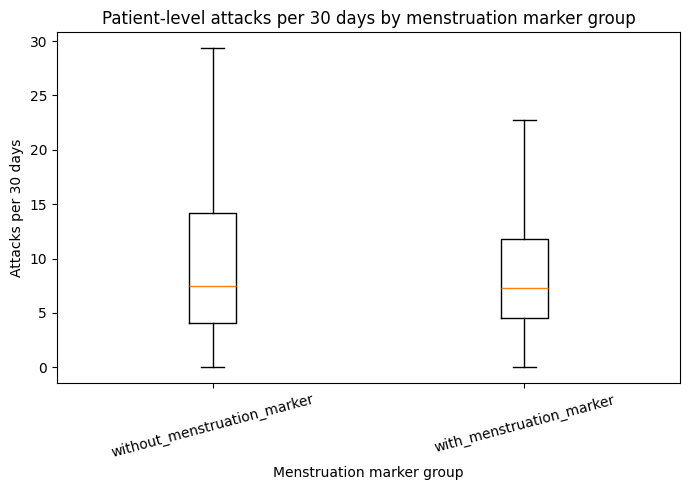

C:\Users\prath\AppData\Local\Temp\ipykernel_21084\2268502000.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


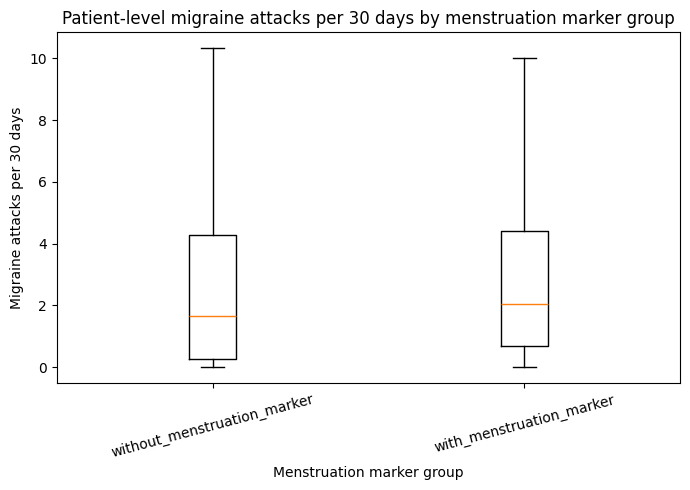

C:\Users\prath\AppData\Local\Temp\ipykernel_21084\2268502000.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


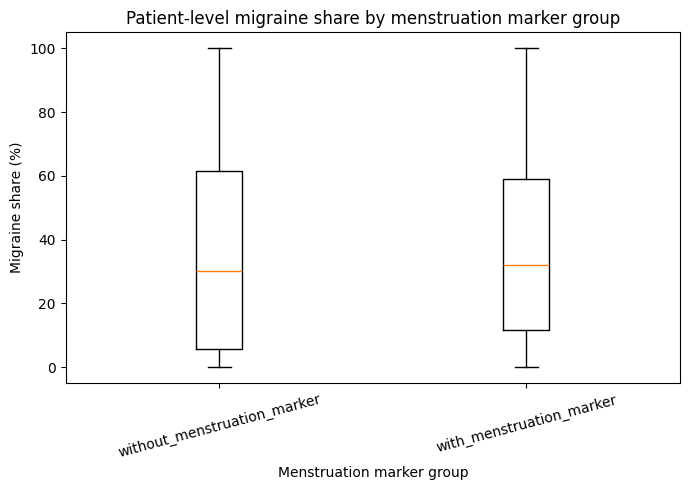

In [30]:

boxplot_burden_by_marker(
    female_burden_analysis,
    "attacks_per_30_days",
    "Patient-level attacks per 30 days by menstruation marker group",
    "Attacks per 30 days"
)

boxplot_burden_by_marker(
    female_burden_analysis,
    "migraine_attacks_per_30_days",
    "Patient-level migraine attacks per 30 days by menstruation marker group",
    "Migraine attacks per 30 days"
)

boxplot_burden_by_marker(
    female_burden_analysis,
    "migraine_share",
    "Patient-level migraine share by menstruation marker group",
    "Migraine share (%)"
)

In [31]:
# Helper function for Kruswall tests

from scipy.stats import kruskal

ALPHA = 0.05

def calculate_epsilon_squared(H, k, n):
    epsilon_squared = (H - k + 1) / (n - k)
    epsilon_squared = max(0, epsilon_squared)
    return epsilon_squared


def interpret_epsilon_squared(epsilon):
    if epsilon < 0.01:
        return "very small / negligible"
    elif epsilon < 0.06:
        return "small"
    elif epsilon < 0.14:
        return "medium"
    else:
        return "large"


def holm_correction(p_values):
    p_values = np.array(p_values)
    m = len(p_values)

    sorted_indices = np.argsort(p_values)
    sorted_p_values = p_values[sorted_indices]

    adjusted_sorted_p_values = np.empty(m)

    for i in range(m):
        adjusted_sorted_p_values[i] = sorted_p_values[i] * (m - i)

    adjusted_sorted_p_values = np.maximum.accumulate(adjusted_sorted_p_values)
    adjusted_sorted_p_values = np.minimum(adjusted_sorted_p_values, 1)

    adjusted_p_values = np.empty(m)
    adjusted_p_values[sorted_indices] = adjusted_sorted_p_values

    return adjusted_p_values

In [32]:
def run_burden_kruskal_test(df, value_col):
    group_order = [
        "without_menstruation_marker",
        "with_menstruation_marker"
    ]

    groups = []
    group_sizes = []

    for group in group_order:
        values = df.loc[
            df["menstruation_marker_group"] == group,
            value_col
        ].dropna()

        groups.append(values)
        group_sizes.append({
            "group": group,
            "n_patients": len(values),
            "median": values.median(),
            "q1": values.quantile(0.25),
            "q3": values.quantile(0.75)
        })

    H_statistic, p_value = kruskal(*groups)

    result = {
        "outcome": value_col,
        "group_variable": "menstruation_marker_group",
        "number_of_groups": len(groups),
        "total_valid_values": sum(len(g) for g in groups),
        "H_statistic": H_statistic,
        "df": len(groups) - 1,
        "p_raw": p_value,
        "median_without_marker": groups[0].median(),
        "median_with_marker": groups[1].median(),
        "median_difference_with_minus_without": groups[1].median() - groups[0].median()
    }

    return result, pd.DataFrame(group_sizes)

In [33]:
burden_tests_to_run = [
    "attacks_per_30_days",
    "migraine_attacks_per_30_days",
    "migraine_share"
]

burden_kruskal_results_list = []

for value_col in burden_tests_to_run:
    result, group_sizes = run_burden_kruskal_test(
        df=female_burden_analysis,
        value_col=value_col
    )

    burden_kruskal_results_list.append(result)

    print("\n" + "=" * 80)
    print(f"Kruskal-Wallis test: {value_col} by menstruation marker group")
    print("=" * 80)

    print("Significance level alpha:", ALPHA)
    print("Confidence level:", int((1 - ALPHA) * 100), "%")

    print("\nHypotheses:")
    print("H0: The distribution is the same for women with and without menstruation marker.")
    print("H1: The distribution differs between women with and without menstruation marker.")

    print("\nGroup sizes and descriptive statistics:")
    display(group_sizes)

    print("\nTest result:")
    print("H statistic:", result["H_statistic"])
    print("df:", result["df"])
    print("raw p-value:", result["p_raw"])
    print("raw p-value scientific:", f"{result['p_raw']:.3e}")

    print("\nPreliminary decision before Holm correction:")
    if result["p_raw"] < ALPHA:
        print("p < alpha → reject H0 before multiple-testing correction.")
    else:
        print("p >= alpha → do not reject H0 before multiple-testing correction.")


Kruskal-Wallis test: attacks_per_30_days by menstruation marker group
Significance level alpha: 0.05
Confidence level: 95 %

Hypotheses:
H0: The distribution is the same for women with and without menstruation marker.
H1: The distribution differs between women with and without menstruation marker.

Group sizes and descriptive statistics:


,group,n_patients,median,q1,q3
0,without_menstruation_marker,41177,7.500000,4.066986,14.178082
1,with_menstruation_marker,8864,7.261526,4.509202,11.814390



Test result:
H statistic: 11.482445660376598
df: 1
raw p-value: 0.0007025661837913866
raw p-value scientific: 7.026e-04

Preliminary decision before Holm correction:
p < alpha → reject H0 before multiple-testing correction.

Kruskal-Wallis test: migraine_attacks_per_30_days by menstruation marker group
Significance level alpha: 0.05
Confidence level: 95 %

Hypotheses:
H0: The distribution is the same for women with and without menstruation marker.
H1: The distribution differs between women with and without menstruation marker.

Group sizes and descriptive statistics:


,group,n_patients,median,q1,q3
0,without_menstruation_marker,41177,1.636364,0.257880,4.285714
1,with_menstruation_marker,8864,2.040816,0.669145,4.405626



Test result:
H statistic: 171.26758500540294
df: 1
raw p-value: 3.91128219638883e-39
raw p-value scientific: 3.911e-39

Preliminary decision before Holm correction:
p < alpha → reject H0 before multiple-testing correction.

Kruskal-Wallis test: migraine_share by menstruation marker group
Significance level alpha: 0.05
Confidence level: 95 %

Hypotheses:
H0: The distribution is the same for women with and without menstruation marker.
H1: The distribution differs between women with and without menstruation marker.

Group sizes and descriptive statistics:


,group,n_patients,median,q1,q3
0,without_menstruation_marker,41177,30.097087,5.769231,61.538462
1,with_menstruation_marker,8864,31.890305,11.764706,58.832837



Test result:
H statistic: 33.69821545322339
df: 1
raw p-value: 6.435970249799753e-09
raw p-value scientific: 6.436e-09

Preliminary decision before Holm correction:
p < alpha → reject H0 before multiple-testing correction.


In [34]:
burden_kruskal_results = pd.DataFrame(burden_kruskal_results_list)

burden_kruskal_results["p_raw_scientific"] = (
    burden_kruskal_results["p_raw"].apply(lambda p: f"{p:.3e}")
)

burden_kruskal_results["epsilon_squared"] = (
    burden_kruskal_results.apply(
        lambda row: calculate_epsilon_squared(
            H=row["H_statistic"],
            k=row["number_of_groups"],
            n=row["total_valid_values"]
        ),
        axis=1
    )
)

burden_kruskal_results["epsilon_squared_percent"] = (
    burden_kruskal_results["epsilon_squared"] * 100
)

burden_kruskal_results["effect_size_interpretation"] = (
    burden_kruskal_results["epsilon_squared"].apply(
        interpret_epsilon_squared
    )
)

display(burden_kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,median_without_marker,median_with_marker,median_difference_with_minus_without,p_raw_scientific,epsilon_squared,epsilon_squared_percent,effect_size_interpretation
0,attacks_per_30_days,menstruation_marker_group,2,50041,11.482446,1,7.025662e-04,7.500000,7.261526,-0.238474,7.026e-04,0.000209,0.020949,very small / negligible
1,migraine_attacks_per_30_days,menstruation_marker_group,2,50041,171.267585,1,3.911282e-39,1.636364,2.040816,0.404453,3.911e-39,0.003403,0.340270,very small / negligible
2,migraine_share,menstruation_marker_group,2,50041,33.698215,1,6.435970e-09,30.097087,31.890305,1.793217,6.436e-09,0.000653,0.065345,very small / negligible


In [35]:
burden_kruskal_results["p_holm"] = holm_correction(
    burden_kruskal_results["p_raw"]
)

burden_kruskal_results["p_holm_scientific"] = (
    burden_kruskal_results["p_holm"].apply(lambda p: f"{p:.3e}")
)

burden_kruskal_results["significant_after_holm"] = (
    burden_kruskal_results["p_holm"] < ALPHA
)

display(burden_kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,median_without_marker,median_with_marker,median_difference_with_minus_without,p_raw_scientific,epsilon_squared,epsilon_squared_percent,effect_size_interpretation,p_holm,p_holm_scientific,significant_after_holm
0,attacks_per_30_days,menstruation_marker_group,2,50041,11.482446,1,7.025662e-04,7.500000,7.261526,-0.238474,7.026e-04,0.000209,0.020949,very small / negligible,7.025662e-04,7.026e-04,True
1,migraine_attacks_per_30_days,menstruation_marker_group,2,50041,171.267585,1,3.911282e-39,1.636364,2.040816,0.404453,3.911e-39,0.003403,0.340270,very small / negligible,1.173385e-38,1.173e-38,True
2,migraine_share,menstruation_marker_group,2,50041,33.698215,1,6.435970e-09,30.097087,31.890305,1.793217,6.436e-09,0.000653,0.065345,very small / negligible,1.287194e-08,1.287e-08,True


In [36]:
fq5_4_final_results = burden_kruskal_results[
    [
        "outcome",
        "median_without_marker",
        "median_with_marker",
        "median_difference_with_minus_without",
        "H_statistic",
        "df",
        "p_raw_scientific",
        "p_holm_scientific",
        "epsilon_squared",
        "epsilon_squared_percent",
        "effect_size_interpretation",
        "significant_after_holm"
    ]
].copy()

fq5_4_final_results["median_without_marker"] = (
    fq5_4_final_results["median_without_marker"].round(3)
)

fq5_4_final_results["median_with_marker"] = (
    fq5_4_final_results["median_with_marker"].round(3)
)

fq5_4_final_results["median_difference_with_minus_without"] = (
    fq5_4_final_results["median_difference_with_minus_without"].round(3)
)

fq5_4_final_results["H_statistic"] = (
    fq5_4_final_results["H_statistic"].round(3)
)

fq5_4_final_results["epsilon_squared"] = (
    fq5_4_final_results["epsilon_squared"].round(8)
)

fq5_4_final_results["epsilon_squared_percent"] = (
    fq5_4_final_results["epsilon_squared_percent"].round(4)
)

display(fq5_4_final_results)

,outcome,median_without_marker,median_with_marker,median_difference_with_minus_without,H_statistic,df,p_raw_scientific,p_holm_scientific,epsilon_squared,epsilon_squared_percent,effect_size_interpretation,significant_after_holm
0,attacks_per_30_days,7.500,7.262,-0.238,11.482,1,7.026e-04,7.026e-04,0.000209,0.0209,very small / negligible,True
1,migraine_attacks_per_30_days,1.636,2.041,0.404,171.268,1,3.911e-39,1.173e-38,0.003403,0.3403,very small / negligible,True
2,migraine_share,30.097,31.890,1.793,33.698,1,6.436e-09,1.287e-08,0.000653,0.0653,very small / negligible,True


In [37]:
for _, row in fq5_4_final_results.iterrows():
    print("--------------------------------------------------")
    print(f"Outcome: {row['outcome']}")
    print(f"Median without marker: {row['median_without_marker']}")
    print(f"Median with marker: {row['median_with_marker']}")
    print(f"Difference with - without: {row['median_difference_with_minus_without']}")
    print(f"H({int(row['df'])}) = {row['H_statistic']}")
    print(f"raw p-value = {row['p_raw_scientific']}")
    print(f"Holm-corrected p-value = {row['p_holm_scientific']}")
    print(f"epsilon² = {row['epsilon_squared']} ({row['epsilon_squared_percent']}%)")
    print(f"Effect size: {row['effect_size_interpretation']}")

    if row["significant_after_holm"]:
        print("Decision: significant after Holm correction")
    else:
        print("Decision: not significant after Holm correction")

--------------------------------------------------
Outcome: attacks_per_30_days
Median without marker: 7.5
Median with marker: 7.262
Difference with - without: -0.238
H(1) = 11.482
raw p-value = 7.026e-04
Holm-corrected p-value = 7.026e-04
epsilon² = 0.00020949 (0.0209%)
Effect size: very small / negligible
Decision: significant after Holm correction
--------------------------------------------------
Outcome: migraine_attacks_per_30_days
Median without marker: 1.636
Median with marker: 2.041
Difference with - without: 0.404
H(1) = 171.268
raw p-value = 3.911e-39
Holm-corrected p-value = 1.173e-38
epsilon² = 0.0034027 (0.3403%)
Effect size: very small / negligible
Decision: significant after Holm correction
--------------------------------------------------
Outcome: migraine_share
Median without marker: 30.097
Median with marker: 31.89
Difference with - without: 1.793
H(1) = 33.698
raw p-value = 6.436e-09
Holm-corrected p-value = 1.287e-08
epsilon² = 0.00065345 (0.0653%)
Effect size: ve

In [38]:
def kruskal_driver_contribution_two_groups(df, value_col, group_col, group_order):
    """
    Calculates which group contributes to the Kruskal-Wallis statistic.

    This is useful when H0 is rejected but effect size is very small.
    For two groups, it mainly shows:
    - which group has higher/lower ranks
    - how much each group contributes to the Kruskal-Wallis signal
    """

    tmp = df[[value_col, group_col]].dropna().copy()
    tmp = tmp[tmp[group_col].isin(group_order)].copy()

    tmp["_rank"] = tmp[value_col].rank(method="average")

    n_total = len(tmp)
    overall_mean_rank = (n_total + 1) / 2
    overall_median = tmp[value_col].median()

    group_summary = (
        tmp
        .groupby(group_col, observed=True)
        .agg(
            n_patients=(value_col, "count"),
            median=(value_col, "median"),
            q1=(value_col, lambda x: x.quantile(0.25)),
            q3=(value_col, lambda x: x.quantile(0.75)),
            mean_rank=("_rank", "mean")
        )
        .reindex(group_order)
        .reset_index()
    )

    group_summary["iqr"] = group_summary["q3"] - group_summary["q1"]

    group_summary["median_difference_from_overall"] = (
        group_summary["median"] - overall_median
    )

    group_summary["mean_rank_difference_from_overall"] = (
        group_summary["mean_rank"] - overall_mean_rank
    )

    group_summary["contribution_raw"] = (
        group_summary["n_patients"]
        * group_summary["mean_rank_difference_from_overall"] ** 2
    )

    group_summary["contribution_percent"] = (
        group_summary["contribution_raw"]
        / group_summary["contribution_raw"].sum()
        * 100
    )

    group_summary["rank_direction"] = np.where(
        group_summary["mean_rank_difference_from_overall"] > 0,
        "higher than overall",
        "lower than overall"
    )

    group_summary = group_summary[
        [
            group_col,
            "n_patients",
            "median",
            "q1",
            "q3",
            "iqr",
            "median_difference_from_overall",
            "mean_rank",
            "mean_rank_difference_from_overall",
            "rank_direction",
            "contribution_percent"
        ]
    ].copy()

    numeric_cols = [
        "median",
        "q1",
        "q3",
        "iqr",
        "median_difference_from_overall",
        "mean_rank",
        "mean_rank_difference_from_overall",
        "contribution_percent"
    ]

    for col in numeric_cols:
        group_summary[col] = group_summary[col].round(3)

    return group_summary

In [39]:
burden_driver_tables = {}

group_order_marker = [
    "without_menstruation_marker",
    "with_menstruation_marker"
]

for value_col in burden_tests_to_run:
    driver_table = kruskal_driver_contribution_two_groups(
        df=female_burden_analysis,
        value_col=value_col,
        group_col="menstruation_marker_group",
        group_order=group_order_marker
    )

    burden_driver_tables[value_col] = driver_table

    print("\n" + "=" * 80)
    print(f"Kruskal-Wallis drivers for: {value_col}")
    print("=" * 80)

    display(driver_table)


Kruskal-Wallis drivers for: attacks_per_30_days


,menstruation_marker_group,n_patients,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
0,without_menstruation_marker,41177,7.500,4.067,14.178,10.111,0.056,25122.487,101.487,higher than overall,17.713
1,with_menstruation_marker,8864,7.262,4.509,11.814,7.305,-0.182,24549.550,-471.450,lower than overall,82.287



Kruskal-Wallis drivers for: migraine_attacks_per_30_days


,menstruation_marker_group,n_patients,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
0,without_menstruation_marker,41177,1.636,0.258,4.286,4.028,-0.078,24630.085,-390.915,lower than overall,17.713
1,with_menstruation_marker,8864,2.041,0.669,4.406,3.736,0.327,26836.966,1815.966,higher than overall,82.287



Kruskal-Wallis drivers for: migraine_share


,menstruation_marker_group,n_patients,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
0,without_menstruation_marker,41177,30.097,5.769,61.538,55.769,-0.622,24847.622,-173.378,lower than overall,17.713
1,with_menstruation_marker,8864,31.890,11.765,58.833,47.068,1.171,25826.413,805.413,higher than overall,82.287


In [40]:
burden_driver_summary_list = []

for value_col, driver_table in burden_driver_tables.items():
    for _, row in driver_table.iterrows():
        burden_driver_summary_list.append({
            "outcome": value_col,
            "group": row["menstruation_marker_group"],
            "median": row["median"],
            "rank_direction": row["rank_direction"],
            "mean_rank_difference_from_overall": row["mean_rank_difference_from_overall"],
            "contribution_percent": row["contribution_percent"]
        })

burden_driver_summary = pd.DataFrame(burden_driver_summary_list)

display(burden_driver_summary)

,outcome,group,median,rank_direction,mean_rank_difference_from_overall,contribution_percent
0,attacks_per_30_days,without_menstruation_marker,7.500,higher than overall,101.487,17.713
1,attacks_per_30_days,with_menstruation_marker,7.262,lower than overall,-471.450,82.287
2,migraine_attacks_per_30_days,without_menstruation_marker,1.636,lower than overall,-390.915,17.713
3,migraine_attacks_per_30_days,with_menstruation_marker,2.041,higher than overall,1815.966,82.287
4,migraine_share,without_menstruation_marker,30.097,lower than overall,-173.378,17.713
5,migraine_share,with_menstruation_marker,31.890,higher than overall,805.413,82.287


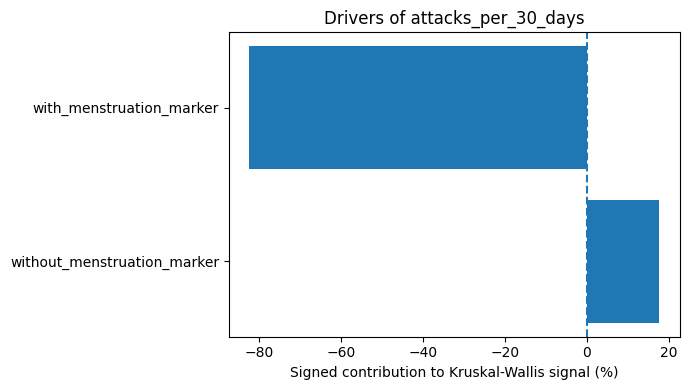

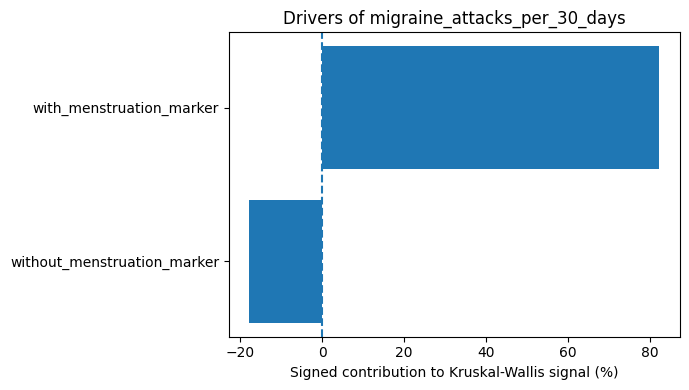

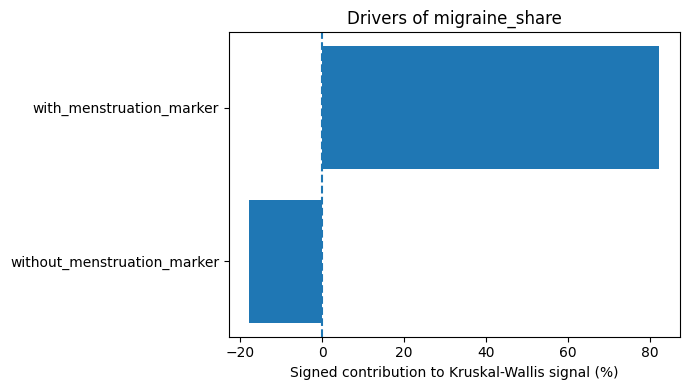

In [41]:
def plot_burden_driver_contribution(driver_table, outcome_name):
    plot_df = driver_table.copy()

    plot_df["signed_contribution_percent"] = np.where(
        plot_df["rank_direction"] == "higher than overall",
        plot_df["contribution_percent"],
        -plot_df["contribution_percent"]
    )

    plt.figure(figsize=(7, 4))
    plt.barh(
        plot_df["menstruation_marker_group"],
        plot_df["signed_contribution_percent"]
    )
    plt.axvline(0, linestyle="--")
    plt.xlabel("Signed contribution to Kruskal-Wallis signal (%)")
    plt.title(f"Drivers of {outcome_name}")
    plt.tight_layout()
    plt.show()
for value_col, driver_table in burden_driver_tables.items():
    plot_burden_driver_contribution(
        driver_table=driver_table,
        outcome_name=value_col
    )


In [42]:
# ------------------------------------------------------------
# Step 5.5: Individual-patient 4-week rhythm analysis
# ------------------------------------------------------------

MIN_OBSERVATION_DAYS = 84
MIN_TOTAL_ATTACKS = 5
MIN_UNIQUE_MENSTRUATION_DATES = 3

CYCLE_MIN_DAYS = 21
CYCLE_MAX_DAYS = 35

print("Eligibility criteria:")
print("Female patients only")
print("Minimum observation days:", MIN_OBSERVATION_DAYS)
print("Minimum total attacks:", MIN_TOTAL_ATTACKS)
print("Minimum unique menstruation-marked attack dates:", MIN_UNIQUE_MENSTRUATION_DATES)

print("\n4-week interval definition:")
print(f"Interval between {CYCLE_MIN_DAYS} and {CYCLE_MAX_DAYS} days")

Eligibility criteria:
Female patients only
Minimum observation days: 84
Minimum total attacks: 5
Minimum unique menstruation-marked attack dates: 3

4-week interval definition:
Interval between 21 and 35 days


In [43]:
# Make sure attack_date exists and is a datetime date
df_fq5["attack_date"] = pd.to_datetime(df_fq5["attack_datetime"]).dt.normalize()

female_menstruation_marked_attacks = df_fq5[
    (df_fq5["gender_clean"] == "female")
    & (df_fq5["menstruation_status"] == "true")
    & (df_fq5["attack_date"].notna())
].copy()

print("Female menstruation-marked attack rows:", len(female_menstruation_marked_attacks))
print("Female patients with at least one menstruation-marked attack:",
      female_menstruation_marked_attacks["patient_id"].nunique())

display(
    female_menstruation_marked_attacks[
        ["patient_id", "attack_date", "migraine_flag", "menstruation_status"]
    ].head()
)

Female menstruation-marked attack rows: 79285
Female patients with at least one menstruation-marked attack: 8864


,patient_id,attack_date,migraine_flag,menstruation_status
35568,64067984,2021-07-06,True,true
35695,59336874,2021-07-06,False,true
36048,51253493,2021-06-29,True,true
36065,64067984,2021-07-07,False,true
36073,22335473,2021-07-09,False,true


In [44]:
female_unique_menstruation_dates = (
    female_menstruation_marked_attacks
    .drop_duplicates(subset=["patient_id", "attack_date"])
    .copy()
)

unique_menstruation_date_counts = (
    female_unique_menstruation_dates
    .groupby("patient_id")
    .agg(
        unique_menstruation_marked_dates=("attack_date", "nunique"),
        first_menstruation_marked_date=("attack_date", "min"),
        last_menstruation_marked_date=("attack_date", "max")
    )
    .reset_index()
)

display(unique_menstruation_date_counts.head())

print("Unique menstruation-marked dates per female patient:")
display(unique_menstruation_date_counts["unique_menstruation_marked_dates"].describe())

,patient_id,unique_menstruation_marked_dates,first_menstruation_marked_date,last_menstruation_marked_date
0,10015721,1,2024-05-29,2024-05-29
1,10022353,1,2026-01-10,2026-01-10
2,10041357,3,2025-12-11,2026-02-05
3,10062458,2,2024-07-21,2024-07-22
4,10077852,8,2023-08-05,2025-06-03


Unique menstruation-marked dates per female patient:


count    8864.000000
mean        8.944607
std        15.583132
min         1.000000
25%         2.000000
50%         4.000000
75%         9.000000
max       285.000000
Name: unique_menstruation_marked_dates, dtype: float64

In [45]:
female_patient_observation = patient_observation[
    patient_observation["gender"] == "female"
].copy()

female_patient_rhythm_base = female_patient_observation.merge(
    unique_menstruation_date_counts,
    on="patient_id",
    how="left"
)

female_patient_rhythm_base["unique_menstruation_marked_dates"] = (
    female_patient_rhythm_base["unique_menstruation_marked_dates"]
    .fillna(0)
    .astype(int)
)

eligible_female_rhythm_patients = female_patient_rhythm_base[
    (female_patient_rhythm_base["observation_days_for_rate"] >= MIN_OBSERVATION_DAYS)
    & (female_patient_rhythm_base["total_attacks"] >= MIN_TOTAL_ATTACKS)
    & (female_patient_rhythm_base["unique_menstruation_marked_dates"] >= MIN_UNIQUE_MENSTRUATION_DATES)
].copy()

print("Total female patients:", female_patient_rhythm_base["patient_id"].nunique())
print("Female patients with at least one menstruation-marked date:",
      (female_patient_rhythm_base["unique_menstruation_marked_dates"] >= 1).sum())
print("Eligible female patients for 4-week rhythm analysis:",
      eligible_female_rhythm_patients["patient_id"].nunique())

display(
    eligible_female_rhythm_patients[
        [
            "patient_id",
            "age_reg",
            "age_group",
            "observation_days_for_rate",
            "total_attacks",
            "migraine_attacks",
            "menstruation_true_attacks",
            "unique_menstruation_marked_dates"
        ]
    ].head()
)

Total female patients: 50041
Female patients with at least one menstruation-marked date: 8864
Eligible female patients for 4-week rhythm analysis: 4979


,patient_id,age_reg,age_group,observation_days_for_rate,total_attacks,migraine_attacks,menstruation_true_attacks,unique_menstruation_marked_dates
37,10077852,46.0,45-59,1203,426,9,8,8
39,10082194,28.0,18-29,1249,190,189,4,4
55,10111638,51.0,45-59,378,174,169,19,19
59,10114886,29.0,18-29,343,85,83,5,5
62,10118371,40.0,30-44,1079,107,54,37,37


In [46]:
eligibility_summary = pd.DataFrame({
    "metric": [
        "total_female_patients",
        "female_patients_with_at_least_1_menstruation_marked_date",
        "female_patients_with_at_least_3_menstruation_marked_dates",
        "eligible_female_patients_strict",
        "percentage_of_all_female_patients_eligible",
        "percentage_of_marker_users_eligible"
    ],
    "value": [
        female_patient_rhythm_base["patient_id"].nunique(),
        (female_patient_rhythm_base["unique_menstruation_marked_dates"] >= 1).sum(),
        (female_patient_rhythm_base["unique_menstruation_marked_dates"] >= MIN_UNIQUE_MENSTRUATION_DATES).sum(),
        eligible_female_rhythm_patients["patient_id"].nunique(),
        round(
            eligible_female_rhythm_patients["patient_id"].nunique()
            / female_patient_rhythm_base["patient_id"].nunique()
            * 100,
            2
        ),
        round(
            eligible_female_rhythm_patients["patient_id"].nunique()
            / max((female_patient_rhythm_base["unique_menstruation_marked_dates"] >= 1).sum(), 1)
            * 100,
            2
        )
    ]
})

display(eligibility_summary)

,metric,value
0,total_female_patients,50041.00
1,female_patients_with_at_least_1_menstruation_m...,8864.00
2,female_patients_with_at_least_3_menstruation_m...,5537.00
3,eligible_female_patients_strict,4979.00
4,percentage_of_all_female_patients_eligible,9.95
5,percentage_of_marker_users_eligible,56.17


In [47]:
eligible_patient_ids = set(eligible_female_rhythm_patients["patient_id"])

eligible_menstruation_dates = female_unique_menstruation_dates[
    female_unique_menstruation_dates["patient_id"].isin(eligible_patient_ids)
].copy()

eligible_menstruation_dates = eligible_menstruation_dates.sort_values(
    ["patient_id", "attack_date"]
)

interval_rows = []

for patient_id, group in eligible_menstruation_dates.groupby("patient_id"):
    dates = group["attack_date"].sort_values().drop_duplicates().tolist()

    for i in range(1, len(dates)):
        previous_date = dates[i - 1]
        current_date = dates[i]
        interval_days = (current_date - previous_date).days

        interval_rows.append({
            "patient_id": patient_id,
            "previous_menstruation_marked_date": previous_date,
            "current_menstruation_marked_date": current_date,
            "interval_days": interval_days,
            "is_21_to_35_days": CYCLE_MIN_DAYS <= interval_days <= CYCLE_MAX_DAYS
        })

menstruation_interval_table = pd.DataFrame(interval_rows)

print("Number of interval rows:", len(menstruation_interval_table))
display(menstruation_interval_table.head())

Number of interval rows: 67152


,patient_id,previous_menstruation_marked_date,current_menstruation_marked_date,interval_days,is_21_to_35_days
0,10077852,2023-08-05,2024-04-09,248,False
1,10077852,2024-04-09,2024-08-17,130,False
2,10077852,2024-08-17,2024-08-18,1,False
3,10077852,2024-08-18,2024-09-16,29,True
4,10077852,2024-09-16,2024-12-14,89,False


In [48]:
interval_summary = pd.DataFrame({
    "metric": [
        "total_intervals",
        "intervals_21_to_35_days",
        "percentage_intervals_21_to_35_days",
        "median_interval_days",
        "q1_interval_days",
        "q3_interval_days",
        "minimum_interval_days",
        "maximum_interval_days"
    ],
    "value": [
        len(menstruation_interval_table),
        menstruation_interval_table["is_21_to_35_days"].sum(),
        round(menstruation_interval_table["is_21_to_35_days"].mean() * 100, 2),
        menstruation_interval_table["interval_days"].median(),
        menstruation_interval_table["interval_days"].quantile(0.25),
        menstruation_interval_table["interval_days"].quantile(0.75),
        menstruation_interval_table["interval_days"].min(),
        menstruation_interval_table["interval_days"].max()
    ]
})

display(interval_summary)

,metric,value
0,total_intervals,67152.00
1,intervals_21_to_35_days,14930.00
2,percentage_intervals_21_to_35_days,22.23
3,median_interval_days,2.00
4,q1_interval_days,1.00
5,q3_interval_days,26.00
6,minimum_interval_days,1.00
7,maximum_interval_days,1167.00


In [49]:
patient_rhythm_score = (
    menstruation_interval_table
    .groupby("patient_id")
    .agg(
        number_of_intervals=("interval_days", "count"),
        number_of_21_to_35_day_intervals=("is_21_to_35_days", "sum"),
        median_interval_days=("interval_days", "median"),
        q1_interval_days=("interval_days", lambda x: x.quantile(0.25)),
        q3_interval_days=("interval_days", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

patient_rhythm_score["share_of_21_to_35_day_intervals"] = (
    patient_rhythm_score["number_of_21_to_35_day_intervals"]
    / patient_rhythm_score["number_of_intervals"]
)

patient_rhythm_score["possible_4_week_pattern_share_rule"] = (
    patient_rhythm_score["share_of_21_to_35_day_intervals"] >= 0.5
)

patient_rhythm_score["possible_4_week_pattern_strict_rule"] = (
    patient_rhythm_score["number_of_21_to_35_day_intervals"] >= 2
)

patient_rhythm_score["possible_4_week_pattern_combined"] = (
    patient_rhythm_score["possible_4_week_pattern_share_rule"]
    & patient_rhythm_score["possible_4_week_pattern_strict_rule"]
)

patient_rhythm_score = patient_rhythm_score.merge(
    eligible_female_rhythm_patients[
        [
            "patient_id",
            "age_reg",
            "age_group",
            "observation_days_for_rate",
            "total_attacks",
            "migraine_attacks",
            "menstruation_true_attacks",
            "unique_menstruation_marked_dates"
        ]
    ],
    on="patient_id",
    how="left"
)

display(patient_rhythm_score.head())

,patient_id,number_of_intervals,number_of_21_to_35_day_intervals,median_interval_days,q1_interval_days,q3_interval_days,share_of_21_to_35_day_intervals,possible_4_week_pattern_share_rule,possible_4_week_pattern_strict_rule,possible_4_week_pattern_combined,age_reg,age_group,observation_days_for_rate,total_attacks,migraine_attacks,menstruation_true_attacks,unique_menstruation_marked_dates
0,10077852,7,1,89.0,15.00,150.00,0.142857,False,False,False,46.0,45-59,1203,426,9,8,8
1,10082194,3,0,2.0,2.00,25.00,0.000000,False,False,False,28.0,18-29,1249,190,189,4,4
2,10111638,18,8,22.0,1.25,25.75,0.444444,False,True,False,51.0,45-59,378,174,169,19,19
3,10114886,4,0,1.0,1.00,11.75,0.000000,False,False,False,29.0,18-29,343,85,83,5,5
4,10118371,36,14,15.5,1.00,26.25,0.388889,False,True,False,40.0,30-44,1079,107,54,37,37


In [50]:
total_eligible_patients = patient_rhythm_score["patient_id"].nunique()

patients_share_rule = patient_rhythm_score["possible_4_week_pattern_share_rule"].sum()
patients_strict_rule = patient_rhythm_score["possible_4_week_pattern_strict_rule"].sum()
patients_combined_rule = patient_rhythm_score["possible_4_week_pattern_combined"].sum()

fq5_5_rhythm_summary = pd.DataFrame({
    "metric": [
        "eligible_female_patients",
        "patients_possible_4_week_pattern_share_rule",
        "percentage_possible_4_week_pattern_share_rule",
        "patients_possible_4_week_pattern_strict_rule",
        "percentage_possible_4_week_pattern_strict_rule",
        "patients_possible_4_week_pattern_combined_rule",
        "percentage_possible_4_week_pattern_combined_rule",
        "median_share_21_to_35_day_intervals",
        "q1_share_21_to_35_day_intervals",
        "q3_share_21_to_35_day_intervals"
    ],
    "value": [
        total_eligible_patients,
        patients_share_rule,
        round(patients_share_rule / total_eligible_patients * 100, 2),
        patients_strict_rule,
        round(patients_strict_rule / total_eligible_patients * 100, 2),
        patients_combined_rule,
        round(patients_combined_rule / total_eligible_patients * 100, 2),
        round(patient_rhythm_score["share_of_21_to_35_day_intervals"].median(), 3),
        round(patient_rhythm_score["share_of_21_to_35_day_intervals"].quantile(0.25), 3),
        round(patient_rhythm_score["share_of_21_to_35_day_intervals"].quantile(0.75), 3)
    ]
})

display(fq5_5_rhythm_summary)

,metric,value
0,eligible_female_patients,4979.000
1,patients_possible_4_week_pattern_share_rule,507.000
2,percentage_possible_4_week_pattern_share_rule,10.180
3,patients_possible_4_week_pattern_strict_rule,2361.000
4,percentage_possible_4_week_pattern_strict_rule,47.420
5,patients_possible_4_week_pattern_combined_rule,358.000
6,percentage_possible_4_week_pattern_combined_rule,7.190
7,median_share_21_to_35_day_intervals,0.182
8,q1_share_21_to_35_day_intervals,0.000
9,q3_share_21_to_35_day_intervals,0.333


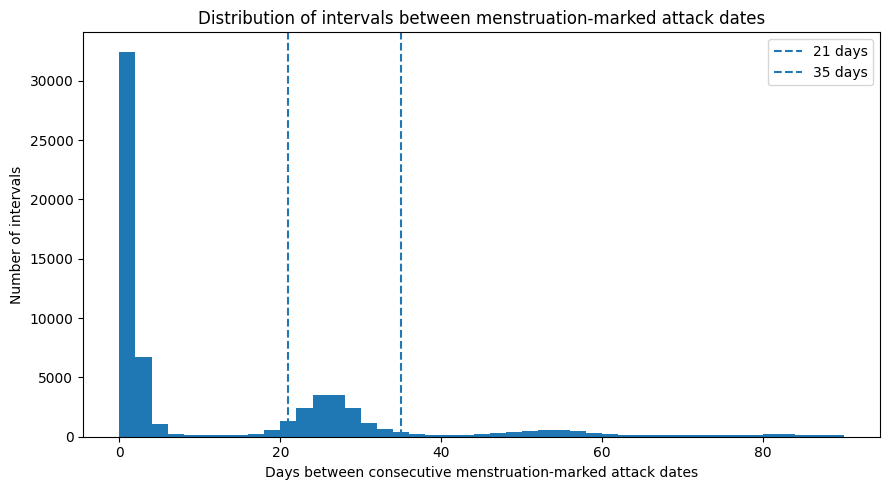

In [51]:
plt.figure(figsize=(9, 5))

plt.hist(
    menstruation_interval_table["interval_days"],
    bins=range(0, 91, 2)
)

plt.axvline(CYCLE_MIN_DAYS, linestyle="--", label="21 days")
plt.axvline(CYCLE_MAX_DAYS, linestyle="--", label="35 days")

plt.xlabel("Days between consecutive menstruation-marked attack dates")
plt.ylabel("Number of intervals")
plt.title("Distribution of intervals between menstruation-marked attack dates")
plt.legend()
plt.tight_layout()
plt.show()

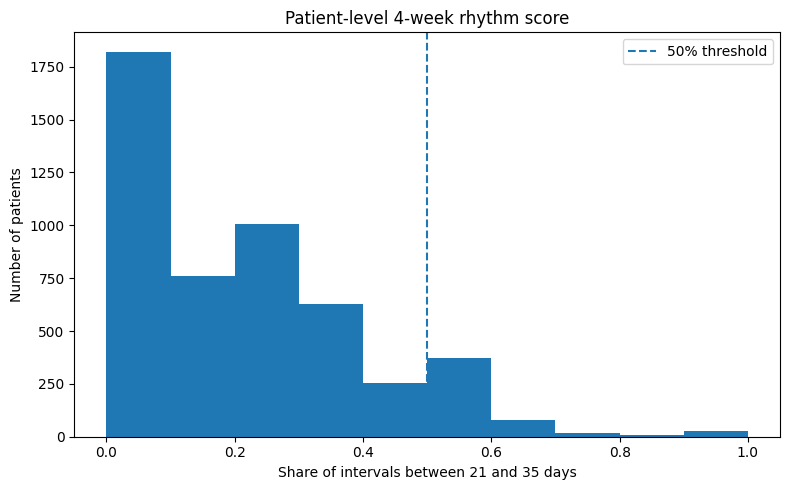

In [52]:
plt.figure(figsize=(8, 5))

plt.hist(
    patient_rhythm_score["share_of_21_to_35_day_intervals"],
    bins=np.linspace(0, 1, 11)
)

plt.axvline(0.5, linestyle="--", label="50% threshold")

plt.xlabel("Share of intervals between 21 and 35 days")
plt.ylabel("Number of patients")
plt.title("Patient-level 4-week rhythm score")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
rhythm_by_age_group = (
    patient_rhythm_score
    .groupby("age_group", observed=True)
    .agg(
        eligible_patients=("patient_id", "nunique"),
        patients_combined_pattern=("possible_4_week_pattern_combined", "sum"),
        median_share_21_35=("share_of_21_to_35_day_intervals", "median"),
        median_unique_menstruation_dates=("unique_menstruation_marked_dates", "median"),
        median_observation_days=("observation_days_for_rate", "median")
    )
    .reset_index()
)

rhythm_by_age_group["percentage_combined_pattern"] = (
    rhythm_by_age_group["patients_combined_pattern"]
    / rhythm_by_age_group["eligible_patients"]
    * 100
).round(2)

display(rhythm_by_age_group)

,age_group,eligible_patients,patients_combined_pattern,median_share_21_35,median_unique_menstruation_dates,median_observation_days,percentage_combined_pattern
0,18-29,1739,109,0.153846,7.0,411.0,6.27
1,30-44,2408,207,0.200000,8.0,461.0,8.60
2,45-59,830,42,0.153846,9.0,514.0,5.06
3,60+,2,0,0.000000,5.0,394.5,0.00


In [54]:
example_pattern_patients = patient_rhythm_score[
    patient_rhythm_score["possible_4_week_pattern_combined"] == True
].sort_values(
    ["share_of_21_to_35_day_intervals", "number_of_21_to_35_day_intervals"],
    ascending=False
)

display(example_pattern_patients.head(10))

,patient_id,number_of_intervals,number_of_21_to_35_day_intervals,median_interval_days,q1_interval_days,q3_interval_days,share_of_21_to_35_day_intervals,possible_4_week_pattern_share_rule,possible_4_week_pattern_strict_rule,possible_4_week_pattern_combined,age_reg,age_group,observation_days_for_rate,total_attacks,migraine_attacks,menstruation_true_attacks,unique_menstruation_marked_dates
1390,35870641,4,4,30.5,29.75,31.75,1.0,True,True,True,19.0,18-29,163,91,15,5,5
3325,70270412,4,4,27.0,27.00,27.75,1.0,True,True,True,34.0,30-44,306,90,22,5,5
482,18671817,3,3,29.0,26.50,30.50,1.0,True,True,True,20.0,18-29,113,88,60,4,4
1726,41365686,3,3,25.0,24.00,28.50,1.0,True,True,True,36.0,30-44,161,6,0,4,4
2906,62577786,3,3,27.0,27.00,27.50,1.0,True,True,True,40.0,30-44,168,52,28,4,4
3130,66896352,3,3,28.0,28.00,28.50,1.0,True,True,True,37.0,30-44,227,205,30,4,4
3999,82761210,3,3,29.0,28.50,30.00,1.0,True,True,True,33.0,30-44,92,7,1,4,4
31,10556600,2,2,29.5,28.75,30.25,1.0,True,True,True,22.0,18-29,907,130,63,3,3
68,11311146,2,2,25.0,24.00,26.00,1.0,True,True,True,36.0,30-44,162,28,16,3,3
118,12157768,2,2,24.0,24.00,24.00,1.0,True,True,True,43.0,30-44,105,7,1,3,3


In [55]:
# Replace this with one patient_id from example_pattern_patients
example_patient_id = example_pattern_patients["patient_id"].iloc[0]

example_patient_intervals = menstruation_interval_table[
    menstruation_interval_table["patient_id"] == example_patient_id
].copy()

print("Example patient:", example_patient_id)
display(example_patient_intervals)

Example patient: 35870641


,patient_id,previous_menstruation_marked_date,current_menstruation_marked_date,interval_days,is_21_to_35_days
19439,35870641,2025-02-19,2025-03-25,34,True
19440,35870641,2025-03-25,2025-04-23,29,True
19441,35870641,2025-04-23,2025-05-24,31,True
19442,35870641,2025-05-24,2025-06-23,30,True


In [56]:
# ------------------------------------------------------------
# Step 5.6: Comparison with men
# 4-week rhythm in migraine attack dates
# ------------------------------------------------------------

MIN_OBSERVATION_DAYS_56 = 84
MIN_TOTAL_ATTACKS_56 = 5
MIN_UNIQUE_MIGRAINE_DATES_56 = 3

CYCLE_MIN_DAYS = 21
CYCLE_MAX_DAYS = 35

ALPHA = 0.05

print("5.6 eligibility criteria:")
print("Gender: female or male")
print("Minimum observation days:", MIN_OBSERVATION_DAYS_56)
print("Minimum total attacks:", MIN_TOTAL_ATTACKS_56)
print("Minimum unique migraine attack dates:", MIN_UNIQUE_MIGRAINE_DATES_56)

print("\n4-week interval definition:")
print(f"Interval between {CYCLE_MIN_DAYS} and {CYCLE_MAX_DAYS} days")

5.6 eligibility criteria:
Gender: female or male
Minimum observation days: 84
Minimum total attacks: 5
Minimum unique migraine attack dates: 3

4-week interval definition:
Interval between 21 and 35 days


In [57]:
# Make sure attack_date exists
df_fq5["attack_date"] = pd.to_datetime(df_fq5["attack_datetime"]).dt.normalize()

migraine_attacks_gender = df_fq5[
    (df_fq5["gender_clean"].isin(["female", "male"]))
    & (df_fq5["migraine_flag"] == True)
    & (df_fq5["attack_date"].notna())
].copy()

print("Migraine attack rows from female/male patients:", len(migraine_attacks_gender))
print("Patients with at least one migraine attack:",
      migraine_attacks_gender["patient_id"].nunique())

display(
    migraine_attacks_gender[
        ["patient_id", "gender_clean", "attack_date", "migraine_flag"]
    ].head()
)

Migraine attack rows from female/male patients: 1589445
Patients with at least one migraine attack: 48555


,patient_id,gender_clean,attack_date,migraine_flag
1,72741515,male,2020-06-09,True
2,44203359,female,2020-06-19,True
3,44203359,female,2020-06-20,True
4,44203359,female,2020-06-21,True
5,44203359,female,2020-06-22,True


In [58]:
unique_migraine_dates_gender = (
    migraine_attacks_gender
    .drop_duplicates(subset=["patient_id", "attack_date"])
    .copy()
)

unique_migraine_date_counts = (
    unique_migraine_dates_gender
    .groupby("patient_id")
    .agg(
        unique_migraine_dates=("attack_date", "nunique"),
        first_migraine_date=("attack_date", "min"),
        last_migraine_date=("attack_date", "max")
    )
    .reset_index()
)

print("Unique migraine-date rows:", len(unique_migraine_dates_gender))

display(unique_migraine_date_counts.head())
display(unique_migraine_date_counts["unique_migraine_dates"].describe())

Unique migraine-date rows: 1589445


,patient_id,unique_migraine_dates,first_migraine_date,last_migraine_date
0,10005708,5,2021-09-14,2021-09-21
1,10005818,16,2025-03-08,2025-12-02
2,10007520,10,2023-07-02,2024-09-14
3,10009199,2,2025-09-28,2025-10-14
4,10011017,64,2025-05-28,2026-02-14


count    48555.000000
mean        32.734940
std         70.299338
min          1.000000
25%          3.000000
50%          8.000000
75%         30.000000
max       1820.000000
Name: unique_migraine_dates, dtype: float64

In [59]:
gender_patient_observation = patient_observation[
    patient_observation["gender"].isin(["female", "male"])
].copy()

gender_patient_rhythm_base = gender_patient_observation.merge(
    unique_migraine_date_counts,
    on="patient_id",
    how="left"
)

gender_patient_rhythm_base["unique_migraine_dates"] = (
    gender_patient_rhythm_base["unique_migraine_dates"]
    .fillna(0)
    .astype(int)
)

eligible_gender_migraine_patients = gender_patient_rhythm_base[
    (gender_patient_rhythm_base["observation_days_for_rate"] >= MIN_OBSERVATION_DAYS_56)
    & (gender_patient_rhythm_base["total_attacks"] >= MIN_TOTAL_ATTACKS_56)
    & (gender_patient_rhythm_base["unique_migraine_dates"] >= MIN_UNIQUE_MIGRAINE_DATES_56)
].copy()

print("Total female/male patients:", gender_patient_rhythm_base["patient_id"].nunique())
print("Eligible patients for 5.6:", eligible_gender_migraine_patients["patient_id"].nunique())

display(
    eligible_gender_migraine_patients[
        [
            "patient_id",
            "gender",
            "age_reg",
            "age_group",
            "observation_days_for_rate",
            "total_attacks",
            "migraine_attacks",
            "unique_migraine_dates"
        ]
    ].head()
)

Total female/male patients: 61214
Eligible patients for 5.6: 28724


,patient_id,gender,age_reg,age_group,observation_days_for_rate,total_attacks,migraine_attacks,unique_migraine_dates
2,10005818,female,57.0,45-59,270,22,16,16
3,10007520,female,61.0,60+,517,122,10,10
6,10011017,female,28.0,18-29,273,243,64,64
8,10014227,female,37.0,30-44,617,80,5,5
9,10015721,female,26.0,18-29,745,122,21,21


In [60]:
eligibility_56_summary = (
    gender_patient_rhythm_base
    .groupby("gender", observed=True)
    .agg(
        total_patients=("patient_id", "nunique"),
        patients_with_at_least_1_migraine_date=("unique_migraine_dates", lambda x: (x >= 1).sum()),
        patients_with_at_least_3_migraine_dates=("unique_migraine_dates", lambda x: (x >= 3).sum())
    )
    .reset_index()
)

eligible_counts = (
    eligible_gender_migraine_patients
    .groupby("gender", observed=True)
    .agg(
        eligible_patients=("patient_id", "nunique")
    )
    .reset_index()
)

eligibility_56_summary = eligibility_56_summary.merge(
    eligible_counts,
    on="gender",
    how="left"
)

eligibility_56_summary["eligible_patients"] = (
    eligibility_56_summary["eligible_patients"]
    .fillna(0)
    .astype(int)
)

eligibility_56_summary["percentage_eligible"] = (
    eligibility_56_summary["eligible_patients"]
    / eligibility_56_summary["total_patients"]
    * 100
).round(2)

display(eligibility_56_summary)

,gender,total_patients,patients_with_at_least_1_migraine_date,patients_with_at_least_3_migraine_dates,eligible_patients,percentage_eligible
0,female,50041,40927,31301,24547,49.05
1,male,11173,7628,5341,4177,37.38


In [61]:
eligible_gender_patient_ids = set(eligible_gender_migraine_patients["patient_id"])

eligible_migraine_dates_gender = unique_migraine_dates_gender[
    unique_migraine_dates_gender["patient_id"].isin(eligible_gender_patient_ids)
].copy()

eligible_migraine_dates_gender = eligible_migraine_dates_gender.sort_values(
    ["patient_id", "attack_date"]
)

migraine_interval_rows = []

for patient_id, group in eligible_migraine_dates_gender.groupby("patient_id"):
    dates = group["attack_date"].sort_values().drop_duplicates().tolist()
    gender_value = group["gender_clean"].iloc[0]

    for i in range(1, len(dates)):
        previous_date = dates[i - 1]
        current_date = dates[i]
        interval_days = (current_date - previous_date).days

        migraine_interval_rows.append({
            "patient_id": patient_id,
            "gender": gender_value,
            "previous_migraine_date": previous_date,
            "current_migraine_date": current_date,
            "interval_days": interval_days,
            "is_21_to_35_days": CYCLE_MIN_DAYS <= interval_days <= CYCLE_MAX_DAYS
        })

migraine_interval_table_gender = pd.DataFrame(migraine_interval_rows)

print("Number of migraine interval rows:", len(migraine_interval_table_gender))
display(migraine_interval_table_gender.head())

Number of migraine interval rows: 1484273


,patient_id,gender,previous_migraine_date,current_migraine_date,interval_days,is_21_to_35_days
0,10005818,female,2025-03-08,2025-03-10,2,False
1,10005818,female,2025-03-10,2025-03-16,6,False
2,10005818,female,2025-03-16,2025-03-17,1,False
3,10005818,female,2025-03-17,2025-03-18,1,False
4,10005818,female,2025-03-18,2025-04-09,22,True


In [62]:
migraine_interval_summary_by_gender = (
    migraine_interval_table_gender
    .groupby("gender", observed=True)
    .agg(
        total_intervals=("interval_days", "count"),
        intervals_21_to_35_days=("is_21_to_35_days", "sum"),
        median_interval_days=("interval_days", "median"),
        q1_interval_days=("interval_days", lambda x: x.quantile(0.25)),
        q3_interval_days=("interval_days", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

migraine_interval_summary_by_gender["percentage_intervals_21_to_35_days"] = (
    migraine_interval_summary_by_gender["intervals_21_to_35_days"]
    / migraine_interval_summary_by_gender["total_intervals"]
    * 100
).round(2)

display(migraine_interval_summary_by_gender)

,gender,total_intervals,intervals_21_to_35_days,median_interval_days,q1_interval_days,q3_interval_days,percentage_intervals_21_to_35_days
0,female,1268827,56718,3.0,1.0,7.0,4.47
1,male,215446,7917,3.0,1.0,7.0,3.67


In [63]:
patient_migraine_rhythm_score_gender = (
    migraine_interval_table_gender
    .groupby(["patient_id", "gender"], observed=True)
    .agg(
        number_of_intervals=("interval_days", "count"),
        number_of_21_to_35_day_intervals=("is_21_to_35_days", "sum"),
        median_interval_days=("interval_days", "median"),
        q1_interval_days=("interval_days", lambda x: x.quantile(0.25)),
        q3_interval_days=("interval_days", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

patient_migraine_rhythm_score_gender["share_of_21_to_35_day_intervals"] = (
    patient_migraine_rhythm_score_gender["number_of_21_to_35_day_intervals"]
    / patient_migraine_rhythm_score_gender["number_of_intervals"]
)

patient_migraine_rhythm_score_gender["possible_4_week_migraine_pattern_share_rule"] = (
    patient_migraine_rhythm_score_gender["share_of_21_to_35_day_intervals"] >= 0.5
)

patient_migraine_rhythm_score_gender["possible_4_week_migraine_pattern_strict_rule"] = (
    patient_migraine_rhythm_score_gender["number_of_21_to_35_day_intervals"] >= 2
)

patient_migraine_rhythm_score_gender["possible_4_week_migraine_pattern_combined"] = (
    patient_migraine_rhythm_score_gender["possible_4_week_migraine_pattern_share_rule"]
    & patient_migraine_rhythm_score_gender["possible_4_week_migraine_pattern_strict_rule"]
)

patient_migraine_rhythm_score_gender = patient_migraine_rhythm_score_gender.merge(
    eligible_gender_migraine_patients[
        [
            "patient_id",
            "age_reg",
            "age_group",
            "observation_days_for_rate",
            "total_attacks",
            "migraine_attacks",
            "unique_migraine_dates"
        ]
    ],
    on="patient_id",
    how="left"
)

display(patient_migraine_rhythm_score_gender.head())

,patient_id,gender,number_of_intervals,number_of_21_to_35_day_intervals,median_interval_days,q1_interval_days,q3_interval_days,share_of_21_to_35_day_intervals,possible_4_week_migraine_pattern_share_rule,possible_4_week_migraine_pattern_strict_rule,possible_4_week_migraine_pattern_combined,age_reg,age_group,observation_days_for_rate,total_attacks,migraine_attacks,unique_migraine_dates
0,10005818,female,15,4,9.0,2.5,25.5,0.266667,False,True,False,57.0,45-59,270,22,16,16
1,10007520,female,9,0,18.0,6.0,56.0,0.000000,False,False,False,61.0,60+,517,122,10,10
2,10011017,female,63,2,2.0,1.0,4.5,0.031746,False,True,False,28.0,18-29,273,243,64,64
3,10014227,female,4,1,171.5,116.5,209.0,0.250000,False,False,False,37.0,30-44,617,80,5,5
4,10015721,female,20,2,19.0,6.0,46.0,0.100000,False,True,False,26.0,18-29,745,122,21,21


In [64]:
migraine_rhythm_by_gender = (
    patient_migraine_rhythm_score_gender
    .groupby("gender", observed=True)
    .agg(
        eligible_patients=("patient_id", "nunique"),
        patients_possible_4_week_pattern=("possible_4_week_migraine_pattern_combined", "sum"),
        median_share_21_to_35_day_intervals=("share_of_21_to_35_day_intervals", "median"),
        q1_share_21_to_35_day_intervals=("share_of_21_to_35_day_intervals", lambda x: x.quantile(0.25)),
        q3_share_21_to_35_day_intervals=("share_of_21_to_35_day_intervals", lambda x: x.quantile(0.75)),
        median_unique_migraine_dates=("unique_migraine_dates", "median"),
        median_observation_days=("observation_days_for_rate", "median")
    )
    .reset_index()
)

migraine_rhythm_by_gender["percentage_possible_4_week_pattern"] = (
    migraine_rhythm_by_gender["patients_possible_4_week_pattern"]
    / migraine_rhythm_by_gender["eligible_patients"]
    * 100
).round(2)

display(migraine_rhythm_by_gender)

,gender,eligible_patients,patients_possible_4_week_pattern,median_share_21_to_35_day_intervals,q1_share_21_to_35_day_intervals,q3_share_21_to_35_day_intervals,median_unique_migraine_dates,median_observation_days,percentage_possible_4_week_pattern
0,female,24547,272,0.052174,0.0,0.142857,23.0,354.0,1.11
1,male,4177,59,0.038462,0.0,0.133333,20.0,370.0,1.41


In [65]:
from scipy.stats import chi2_contingency

contingency_gender_migraine_pattern = pd.crosstab(
    patient_migraine_rhythm_score_gender["gender"],
    patient_migraine_rhythm_score_gender["possible_4_week_migraine_pattern_combined"]
)

contingency_gender_migraine_pattern = contingency_gender_migraine_pattern.reindex(
    index=["female", "male"],
    columns=[False, True],
    fill_value=0
)

contingency_gender_migraine_pattern.columns = [
    "no_possible_4_week_pattern",
    "possible_4_week_pattern"
]

display(contingency_gender_migraine_pattern)

observed_gender_pattern = contingency_gender_migraine_pattern[
    ["no_possible_4_week_pattern", "possible_4_week_pattern"]
].values

chi2_gender_pattern, p_gender_pattern, dof_gender_pattern, expected_gender_pattern = chi2_contingency(
    observed_gender_pattern,
    correction=False
)

expected_gender_pattern_table = pd.DataFrame(
    expected_gender_pattern,
    index=contingency_gender_migraine_pattern.index,
    columns=contingency_gender_migraine_pattern.columns
)

print("Chi-square test: gender vs possible 4-week migraine pattern")
print("=" * 75)

print("Significance level alpha:", ALPHA)
print("Confidence level:", int((1 - ALPHA) * 100), "%")

print("\nHypotheses:")
print("H0: Gender and possible 4-week migraine pattern are independent.")
print("H1: Gender and possible 4-week migraine pattern are associated.")

print("\nObserved frequencies:")
display(contingency_gender_migraine_pattern)

print("\nExpected frequencies under H0:")
display(expected_gender_pattern_table)

print("\nTest result:")
print("Chi2 statistic:", chi2_gender_pattern)
print("Degrees of freedom:", dof_gender_pattern)
print("Raw p-value:", p_gender_pattern)
print("Raw p-value scientific:", f"{p_gender_pattern:.3e}")

print("\nDecision:")
if p_gender_pattern < ALPHA:
    print("p < alpha → reject H0.")
    print("Interpretation: Gender and possible 4-week migraine pattern are statistically associated.")
else:
    print("p >= alpha → do not reject H0.")
    print("Interpretation: No statistically significant association was found.")

,no_possible_4_week_pattern,possible_4_week_pattern
gender,,
female,24275,272
male,4118,59


Chi-square test: gender vs possible 4-week migraine pattern
Significance level alpha: 0.05
Confidence level: 95 %

Hypotheses:
H0: Gender and possible 4-week migraine pattern are independent.
H1: Gender and possible 4-week migraine pattern are associated.

Observed frequencies:


,no_possible_4_week_pattern,possible_4_week_pattern
gender,,
female,24275,272
male,4118,59



Expected frequencies under H0:


,no_possible_4_week_pattern,possible_4_week_pattern
gender,,
female,24264.133512,282.866488
male,4128.866488,48.133512



Test result:
Chi2 statistic: 2.904096115545955
Degrees of freedom: 1
Raw p-value: 0.08835477220488729
Raw p-value scientific: 8.835e-02

Decision:
p >= alpha → do not reject H0.
Interpretation: No statistically significant association was found.


In [66]:
def cramers_v_from_chi2(chi2, n, rows, cols):
    min_dimension = min(rows - 1, cols - 1)
    if min_dimension == 0:
        return np.nan
    return np.sqrt(chi2 / (n * min_dimension))


def interpret_cramers_v(v):
    if pd.isna(v):
        return "not interpretable"
    elif v < 0.1:
        return "very small / negligible"
    elif v < 0.3:
        return "small"
    elif v < 0.5:
        return "medium"
    else:
        return "large"


n_gender_pattern = observed_gender_pattern.sum()
rows_gender_pattern, cols_gender_pattern = observed_gender_pattern.shape

cramers_v_gender_pattern = cramers_v_from_chi2(
    chi2=chi2_gender_pattern,
    n=n_gender_pattern,
    rows=rows_gender_pattern,
    cols=cols_gender_pattern
)

cramers_v_gender_pattern_interpretation = interpret_cramers_v(
    cramers_v_gender_pattern
)

print("Cramer's V:", cramers_v_gender_pattern)
print("Cramer's V interpretation:", cramers_v_gender_pattern_interpretation)

Cramer's V: 0.010055022203171157
Cramer's V interpretation: very small / negligible


In [67]:
female_pattern_percentage = migraine_rhythm_by_gender.loc[
    migraine_rhythm_by_gender["gender"] == "female",
    "percentage_possible_4_week_pattern"
].iloc[0]

male_pattern_percentage = migraine_rhythm_by_gender.loc[
    migraine_rhythm_by_gender["gender"] == "male",
    "percentage_possible_4_week_pattern"
].iloc[0]

percentage_difference_female_minus_male = (
    female_pattern_percentage - male_pattern_percentage
)

fq5_6_final_result = pd.DataFrame({
    "analysis": ["gender_vs_possible_4_week_migraine_pattern"],
    "population": ["eligible female and male patients with repeated migraine dates"],
    "test": ["Chi-square test"],
    "chi2_statistic": [chi2_gender_pattern],
    "df": [dof_gender_pattern],
    "p_raw": [p_gender_pattern],
    "p_raw_scientific": [f"{p_gender_pattern:.3e}"],
    "cramers_v": [cramers_v_gender_pattern],
    "effect_size_interpretation": [cramers_v_gender_pattern_interpretation],
    "female_pattern_percentage": [female_pattern_percentage],
    "male_pattern_percentage": [male_pattern_percentage],
    "difference_percentage_points_female_minus_male": [
        round(percentage_difference_female_minus_male, 2)
    ],
    "n_patients_used": [n_gender_pattern]
})

fq5_6_final_result["chi2_statistic"] = (
    fq5_6_final_result["chi2_statistic"].round(3)
)

fq5_6_final_result["cramers_v"] = (
    fq5_6_final_result["cramers_v"].round(6)
)

display(fq5_6_final_result)

,analysis,population,test,chi2_statistic,df,p_raw,p_raw_scientific,cramers_v,effect_size_interpretation,female_pattern_percentage,male_pattern_percentage,difference_percentage_points_female_minus_male,n_patients_used
0,gender_vs_possible_4_week_migraine_pattern,eligible female and male patients with repeate...,Chi-square test,2.904,1,0.088355,8.835e-02,0.010055,very small / negligible,1.11,1.41,-0.3,28724


In [68]:
observed_gender_pattern_table = contingency_gender_migraine_pattern.copy()

chi_square_contribution_gender = (
    (observed_gender_pattern_table - expected_gender_pattern_table) ** 2
    / expected_gender_pattern_table
)

chi_square_contribution_gender_percent = (
    chi_square_contribution_gender
    / chi_square_contribution_gender.values.sum()
    * 100
)

pearson_residuals_gender = (
    (observed_gender_pattern_table - expected_gender_pattern_table)
    / np.sqrt(expected_gender_pattern_table)
)

print("Cell contributions to Chi-square:")
display(chi_square_contribution_gender.round(3))

print("Cell contribution percentages:")
display(chi_square_contribution_gender_percent.round(2))

print("Pearson residuals:")
display(pearson_residuals_gender.round(3))

Cell contributions to Chi-square:


,no_possible_4_week_pattern,possible_4_week_pattern
gender,,
female,0.005,0.417
male,0.029,2.453


Cell contribution percentages:


,no_possible_4_week_pattern,possible_4_week_pattern
gender,,
female,0.17,14.37
male,0.98,84.47


Pearson residuals:


,no_possible_4_week_pattern,possible_4_week_pattern
gender,,
female,0.070,-0.646
male,-0.169,1.566


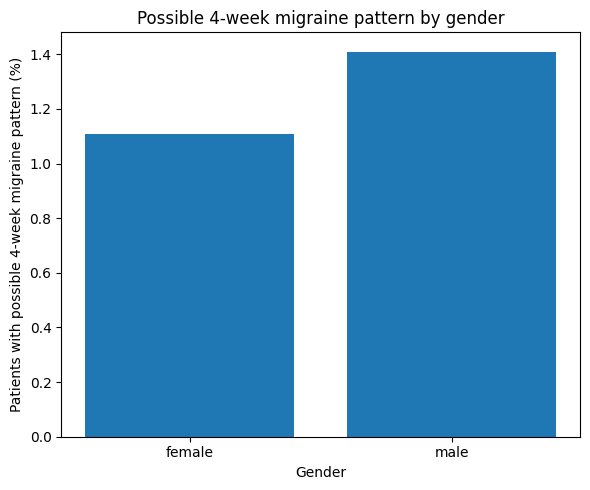

In [69]:
plot_gender_pattern = migraine_rhythm_by_gender.copy()

plt.figure(figsize=(6, 5))

plt.bar(
    plot_gender_pattern["gender"],
    plot_gender_pattern["percentage_possible_4_week_pattern"]
)

plt.xlabel("Gender")
plt.ylabel("Patients with possible 4-week migraine pattern (%)")
plt.title("Possible 4-week migraine pattern by gender")

plt.tight_layout()
plt.show()

In [70]:
# ------------------------------------------------------------
# Step 5.7: Menopause / age-group proxy analysis
# ------------------------------------------------------------

AGE_GROUP_ORDER = ["18-29", "30-44", "45-59", "60+"]
AGE_GROUP_BROAD_ORDER = ["18-44", "45+"]

ALPHA = 0.05

def assign_age_group_proxy(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age < 30:
        return "18-29"
    elif 30 <= age < 45:
        return "30-44"
    elif 45 <= age < 60:
        return "45-59"
    elif age >= 60:
        return "60+"
    else:
        return np.nan


def assign_broad_age_group_proxy(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age < 45:
        return "18-44"
    elif age >= 45:
        return "45+"
    else:
        return np.nan


print("Detailed age groups:", AGE_GROUP_ORDER)
print("Broad menopause-proxy groups:", AGE_GROUP_BROAD_ORDER)

Detailed age groups: ['18-29', '30-44', '45-59', '60+']
Broad menopause-proxy groups: ['18-44', '45+']


In [71]:
female_age_proxy_base = patient_observation[
    patient_observation["gender"] == "female"
].copy()

female_age_proxy_base["age_reg"] = pd.to_numeric(
    female_age_proxy_base["age_reg"],
    errors="coerce"
)

female_age_proxy_base["age_group_proxy"] = (
    female_age_proxy_base["age_reg"].apply(assign_age_group_proxy)
)

female_age_proxy_base["age_group_broad_proxy"] = (
    female_age_proxy_base["age_reg"].apply(assign_broad_age_group_proxy)
)

female_age_proxy_base = female_age_proxy_base[
    female_age_proxy_base["age_group_proxy"].notna()
].copy()

print("Female patients with usable age group:", female_age_proxy_base["patient_id"].nunique())

display(
    female_age_proxy_base[
        [
            "patient_id",
            "age_reg",
            "age_group_proxy",
            "age_group_broad_proxy",
            "total_attacks",
            "migraine_attacks",
            "migraine_attacks_per_30_days",
            "migraine_share",
            "has_menstruation_marker",
            "menstruation_true_attacks"
        ]
    ].head()
)

Female patients with usable age group: 50041


,patient_id,age_reg,age_group_proxy,age_group_broad_proxy,total_attacks,migraine_attacks,migraine_attacks_per_30_days,migraine_share,has_menstruation_marker,menstruation_true_attacks
0,10005187,21.0,18-29,18-44,9,0,0.000000,0.000000,False,0
2,10005818,57.0,45-59,45+,22,16,1.777778,72.727273,False,0
3,10007520,61.0,60+,45+,122,10,0.580271,8.196721,False,0
5,10010442,44.0,30-44,18-44,7,0,0.000000,0.000000,False,0
6,10011017,28.0,18-29,18-44,243,64,7.032967,26.337449,False,0


In [72]:
marker_and_burden_by_age = (
    female_age_proxy_base
    .groupby("age_group_proxy", observed=True)
    .agg(
        female_patients=("patient_id", "nunique"),
        patients_with_menstruation_marker=("has_menstruation_marker", "sum"),
        median_menstruation_true_attacks=("menstruation_true_attacks", "median"),
        median_migraine_attacks_per_30_days=("migraine_attacks_per_30_days", "median"),
        q1_migraine_attacks_per_30_days=("migraine_attacks_per_30_days", lambda x: x.quantile(0.25)),
        q3_migraine_attacks_per_30_days=("migraine_attacks_per_30_days", lambda x: x.quantile(0.75)),
        median_migraine_share=("migraine_share", "median")
    )
    .reindex(AGE_GROUP_ORDER)
    .reset_index()
)

marker_and_burden_by_age["percentage_with_menstruation_marker"] = (
    marker_and_burden_by_age["patients_with_menstruation_marker"]
    / marker_and_burden_by_age["female_patients"]
    * 100
).round(2)

numeric_cols = marker_and_burden_by_age.select_dtypes(include="number").columns
marker_and_burden_by_age[numeric_cols] = marker_and_burden_by_age[numeric_cols].round(3)

display(marker_and_burden_by_age)

,age_group_proxy,female_patients,patients_with_menstruation_marker,median_menstruation_true_attacks,median_migraine_attacks_per_30_days,q1_migraine_attacks_per_30_days,q3_migraine_attacks_per_30_days,median_migraine_share,percentage_with_menstruation_marker
0,18-29,19621,3313,0.0,1.399,0.256,3.667,25.000,16.88
1,30-44,18423,4172,0.0,1.714,0.323,4.375,30.864,22.65
2,45-59,10404,1365,0.0,2.343,0.559,5.265,40.000,13.12
3,60+,1593,14,0.0,2.615,0.577,5.714,44.667,0.88


In [73]:
female_marker_rhythm_age = patient_rhythm_score.copy()

female_marker_rhythm_age["age_reg"] = pd.to_numeric(
    female_marker_rhythm_age["age_reg"],
    errors="coerce"
)

female_marker_rhythm_age["age_group_proxy"] = (
    female_marker_rhythm_age["age_reg"].apply(assign_age_group_proxy)
)

female_marker_rhythm_age["age_group_broad_proxy"] = (
    female_marker_rhythm_age["age_reg"].apply(assign_broad_age_group_proxy)
)

female_marker_rhythm_age = female_marker_rhythm_age[
    female_marker_rhythm_age["age_group_proxy"].notna()
].copy()

marker_rhythm_by_age = (
    female_marker_rhythm_age
    .groupby("age_group_proxy", observed=True)
    .agg(
        eligible_marker_rhythm_patients=("patient_id", "nunique"),
        patients_possible_4_week_marker_pattern=("possible_4_week_pattern_combined", "sum"),
        median_share_21_35_marker_intervals=("share_of_21_to_35_day_intervals", "median"),
        q1_share_21_35_marker_intervals=("share_of_21_to_35_day_intervals", lambda x: x.quantile(0.25)),
        q3_share_21_35_marker_intervals=("share_of_21_to_35_day_intervals", lambda x: x.quantile(0.75)),
        median_unique_menstruation_dates=("unique_menstruation_marked_dates", "median")
    )
    .reindex(AGE_GROUP_ORDER)
    .reset_index()
)

marker_rhythm_by_age["percentage_possible_4_week_marker_pattern"] = (
    marker_rhythm_by_age["patients_possible_4_week_marker_pattern"]
    / marker_rhythm_by_age["eligible_marker_rhythm_patients"]
    * 100
).round(2)

numeric_cols = marker_rhythm_by_age.select_dtypes(include="number").columns
marker_rhythm_by_age[numeric_cols] = marker_rhythm_by_age[numeric_cols].round(3)

display(marker_rhythm_by_age)

,age_group_proxy,eligible_marker_rhythm_patients,patients_possible_4_week_marker_pattern,median_share_21_35_marker_intervals,q1_share_21_35_marker_intervals,q3_share_21_35_marker_intervals,median_unique_menstruation_dates,percentage_possible_4_week_marker_pattern
0,18-29,1739,109,0.154,0.0,0.300,7.0,6.27
1,30-44,2408,207,0.200,0.0,0.333,8.0,8.60
2,45-59,830,42,0.154,0.0,0.291,9.0,5.06
3,60+,2,0,0.000,0.0,0.000,5.0,0.00


In [74]:
female_migraine_rhythm_age = patient_migraine_rhythm_score_gender[
    patient_migraine_rhythm_score_gender["gender"] == "female"
].copy()

female_migraine_rhythm_age["age_reg"] = pd.to_numeric(
    female_migraine_rhythm_age["age_reg"],
    errors="coerce"
)

female_migraine_rhythm_age["age_group_proxy"] = (
    female_migraine_rhythm_age["age_reg"].apply(assign_age_group_proxy)
)

female_migraine_rhythm_age["age_group_broad_proxy"] = (
    female_migraine_rhythm_age["age_reg"].apply(assign_broad_age_group_proxy)
)

female_migraine_rhythm_age = female_migraine_rhythm_age[
    female_migraine_rhythm_age["age_group_proxy"].notna()
].copy()

migraine_rhythm_by_female_age = (
    female_migraine_rhythm_age
    .groupby("age_group_proxy", observed=True)
    .agg(
        eligible_migraine_rhythm_patients=("patient_id", "nunique"),
        patients_possible_4_week_migraine_pattern=("possible_4_week_migraine_pattern_combined", "sum"),
        median_share_21_35_migraine_intervals=("share_of_21_to_35_day_intervals", "median"),
        q1_share_21_35_migraine_intervals=("share_of_21_to_35_day_intervals", lambda x: x.quantile(0.25)),
        q3_share_21_35_migraine_intervals=("share_of_21_to_35_day_intervals", lambda x: x.quantile(0.75)),
        median_unique_migraine_dates=("unique_migraine_dates", "median")
    )
    .reindex(AGE_GROUP_ORDER)
    .reset_index()
)

migraine_rhythm_by_female_age["percentage_possible_4_week_migraine_pattern"] = (
    migraine_rhythm_by_female_age["patients_possible_4_week_migraine_pattern"]
    / migraine_rhythm_by_female_age["eligible_migraine_rhythm_patients"]
    * 100
).round(2)

numeric_cols = migraine_rhythm_by_female_age.select_dtypes(include="number").columns
migraine_rhythm_by_female_age[numeric_cols] = numeric_cols = migraine_rhythm_by_female_age[numeric_cols].round(3)

display(migraine_rhythm_by_female_age)

,age_group_proxy,eligible_migraine_rhythm_patients,patients_possible_4_week_migraine_pattern,median_share_21_35_migraine_intervals,q1_share_21_35_migraine_intervals,q3_share_21_35_migraine_intervals,median_unique_migraine_dates,percentage_possible_4_week_migraine_pattern
0,18-29,8818,126,0.056,0.0,0.150,17.0,1.43
1,30-44,8846,93,0.056,0.0,0.143,23.0,1.05
2,45-59,5957,49,0.045,0.0,0.125,33.0,0.82
3,60+,926,4,0.033,0.0,0.100,40.0,0.43


In [75]:
fq5_7_age_proxy_summary = marker_and_burden_by_age[
    [
        "age_group_proxy",
        "female_patients",
        "patients_with_menstruation_marker",
        "percentage_with_menstruation_marker",
        "median_migraine_attacks_per_30_days",
        "q1_migraine_attacks_per_30_days",
        "q3_migraine_attacks_per_30_days",
        "median_migraine_share"
    ]
].copy()

fq5_7_age_proxy_summary = fq5_7_age_proxy_summary.merge(
    marker_rhythm_by_age[
        [
            "age_group_proxy",
            "eligible_marker_rhythm_patients",
            "patients_possible_4_week_marker_pattern",
            "percentage_possible_4_week_marker_pattern",
            "median_share_21_35_marker_intervals"
        ]
    ],
    on="age_group_proxy",
    how="left"
)

fq5_7_age_proxy_summary = fq5_7_age_proxy_summary.merge(
    migraine_rhythm_by_female_age[
        [
            "age_group_proxy",
            "eligible_migraine_rhythm_patients",
            "patients_possible_4_week_migraine_pattern",
            "percentage_possible_4_week_migraine_pattern",
            "median_share_21_35_migraine_intervals"
        ]
    ],
    on="age_group_proxy",
    how="left"
)

display(fq5_7_age_proxy_summary)

,age_group_proxy,female_patients,patients_with_menstruation_marker,percentage_with_menstruation_marker,median_migraine_attacks_per_30_days,q1_migraine_attacks_per_30_days,q3_migraine_attacks_per_30_days,median_migraine_share,eligible_marker_rhythm_patients,patients_possible_4_week_marker_pattern,percentage_possible_4_week_marker_pattern,median_share_21_35_marker_intervals,eligible_migraine_rhythm_patients,patients_possible_4_week_migraine_pattern,percentage_possible_4_week_migraine_pattern,median_share_21_35_migraine_intervals
0,18-29,19621,3313,16.88,1.399,0.256,3.667,25.000,1739,109,6.27,0.154,8818,126,1.43,0.056
1,30-44,18423,4172,22.65,1.714,0.323,4.375,30.864,2408,207,8.60,0.200,8846,93,1.05,0.056
2,45-59,10404,1365,13.12,2.343,0.559,5.265,40.000,830,42,5.06,0.154,5957,49,0.82,0.045
3,60+,1593,14,0.88,2.615,0.577,5.714,44.667,2,0,0.00,0.000,926,4,0.43,0.033


In [76]:
marker_and_burden_by_broad_age = (
    female_age_proxy_base
    .groupby("age_group_broad_proxy", observed=True)
    .agg(
        female_patients=("patient_id", "nunique"),
        patients_with_menstruation_marker=("has_menstruation_marker", "sum"),
        median_migraine_attacks_per_30_days=("migraine_attacks_per_30_days", "median"),
        q1_migraine_attacks_per_30_days=("migraine_attacks_per_30_days", lambda x: x.quantile(0.25)),
        q3_migraine_attacks_per_30_days=("migraine_attacks_per_30_days", lambda x: x.quantile(0.75)),
        median_migraine_share=("migraine_share", "median")
    )
    .reindex(AGE_GROUP_BROAD_ORDER)
    .reset_index()
)

marker_and_burden_by_broad_age["percentage_with_menstruation_marker"] = (
    marker_and_burden_by_broad_age["patients_with_menstruation_marker"]
    / marker_and_burden_by_broad_age["female_patients"]
    * 100
).round(2)


marker_rhythm_by_broad_age = (
    female_marker_rhythm_age
    .groupby("age_group_broad_proxy", observed=True)
    .agg(
        eligible_marker_rhythm_patients=("patient_id", "nunique"),
        patients_possible_4_week_marker_pattern=("possible_4_week_pattern_combined", "sum"),
        median_share_21_35_marker_intervals=("share_of_21_to_35_day_intervals", "median")
    )
    .reindex(AGE_GROUP_BROAD_ORDER)
    .reset_index()
)

marker_rhythm_by_broad_age["percentage_possible_4_week_marker_pattern"] = (
    marker_rhythm_by_broad_age["patients_possible_4_week_marker_pattern"]
    / marker_rhythm_by_broad_age["eligible_marker_rhythm_patients"]
    * 100
).round(2)


migraine_rhythm_by_broad_age = (
    female_migraine_rhythm_age
    .groupby("age_group_broad_proxy", observed=True)
    .agg(
        eligible_migraine_rhythm_patients=("patient_id", "nunique"),
        patients_possible_4_week_migraine_pattern=("possible_4_week_migraine_pattern_combined", "sum"),
        median_share_21_35_migraine_intervals=("share_of_21_to_35_day_intervals", "median")
    )
    .reindex(AGE_GROUP_BROAD_ORDER)
    .reset_index()
)

migraine_rhythm_by_broad_age["percentage_possible_4_week_migraine_pattern"] = (
    migraine_rhythm_by_broad_age["patients_possible_4_week_migraine_pattern"]
    / migraine_rhythm_by_broad_age["eligible_migraine_rhythm_patients"]
    * 100
).round(2)


fq5_7_broad_age_proxy_summary = marker_and_burden_by_broad_age.merge(
    marker_rhythm_by_broad_age,
    on="age_group_broad_proxy",
    how="left"
).merge(
    migraine_rhythm_by_broad_age,
    on="age_group_broad_proxy",
    how="left"
)

numeric_cols = fq5_7_broad_age_proxy_summary.select_dtypes(include="number").columns
fq5_7_broad_age_proxy_summary[numeric_cols] = fq5_7_broad_age_proxy_summary[numeric_cols].round(3)

display(fq5_7_broad_age_proxy_summary)

,age_group_broad_proxy,female_patients,patients_with_menstruation_marker,median_migraine_attacks_per_30_days,q1_migraine_attacks_per_30_days,q3_migraine_attacks_per_30_days,median_migraine_share,percentage_with_menstruation_marker,eligible_marker_rhythm_patients,patients_possible_4_week_marker_pattern,median_share_21_35_marker_intervals,percentage_possible_4_week_marker_pattern,eligible_migraine_rhythm_patients,patients_possible_4_week_migraine_pattern,median_share_21_35_migraine_intervals,percentage_possible_4_week_migraine_pattern
0,18-44,38044,7485,1.538,0.290,4.000,27.778,19.67,4147,316,0.188,7.62,17664,219,0.056,1.24
1,45+,11997,1379,2.383,0.561,5.328,40.404,11.49,832,42,0.154,5.05,6883,53,0.043,0.77


In [77]:
# Again helper function!!

from scipy.stats import chi2_contingency, kruskal

def cramers_v_from_chi2(chi2, n, rows, cols):
    min_dimension = min(rows - 1, cols - 1)
    if min_dimension == 0:
        return np.nan
    return np.sqrt(chi2 / (n * min_dimension))


def interpret_cramers_v(v):
    if pd.isna(v):
        return "not interpretable"
    elif v < 0.1:
        return "very small / negligible"
    elif v < 0.3:
        return "small"
    elif v < 0.5:
        return "medium"
    else:
        return "large"


def calculate_epsilon_squared(H, k, n):
    epsilon_squared = (H - k + 1) / (n - k)
    return max(0, epsilon_squared)


def interpret_epsilon_squared(epsilon):
    if epsilon < 0.01:
        return "very small / negligible"
    elif epsilon < 0.06:
        return "small"
    elif epsilon < 0.14:
        return "medium"
    else:
        return "large"


def holm_correction(p_values):
    p_values = np.array(p_values, dtype=float)
    m = len(p_values)

    sorted_indices = np.argsort(p_values)
    sorted_p_values = p_values[sorted_indices]

    adjusted_sorted = np.empty(m)

    for i in range(m):
        adjusted_sorted[i] = sorted_p_values[i] * (m - i)

    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)
    adjusted_sorted = np.minimum(adjusted_sorted, 1)

    adjusted = np.empty(m)
    adjusted[sorted_indices] = adjusted_sorted

    return adjusted

In [78]:
def run_age_group_chi_square(df, group_col, outcome_col, group_order, analysis_label):
    tmp = df[[group_col, outcome_col]].dropna().copy()

    tmp = tmp[tmp[group_col].isin(group_order)].copy()
    tmp[outcome_col] = tmp[outcome_col].astype(bool)

    contingency = pd.crosstab(
        tmp[group_col],
        tmp[outcome_col]
    )

    contingency = contingency.reindex(
        index=group_order,
        columns=[False, True],
        fill_value=0
    )

    contingency.columns = ["outcome_false", "outcome_true"]

    observed = contingency[["outcome_false", "outcome_true"]].values

    chi2_statistic, p_value, dof, expected = chi2_contingency(
        observed,
        correction=False
    )

    expected_table = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )

    n_total = observed.sum()
    rows, cols = observed.shape

    cramers_v = cramers_v_from_chi2(
        chi2=chi2_statistic,
        n=n_total,
        rows=rows,
        cols=cols
    )

    result = {
        "analysis": analysis_label,
        "test": "Chi-square test",
        "group_variable": group_col,
        "outcome": outcome_col,
        "n_patients": n_total,
        "chi2_statistic": chi2_statistic,
        "df": dof,
        "p_raw": p_value,
        "effect_size": cramers_v,
        "effect_size_type": "Cramer's V",
        "effect_size_interpretation": interpret_cramers_v(cramers_v)
    }

    return result, contingency, expected_table

In [79]:
def run_age_group_kruskal(df, group_col, value_col, group_order, analysis_label):
    tmp = df[[group_col, value_col]].dropna().copy()
    tmp = tmp[tmp[group_col].isin(group_order)].copy()

    groups = []

    for group in group_order:
        values = tmp.loc[tmp[group_col] == group, value_col].dropna()
        if len(values) > 0:
            groups.append(values)

    H_statistic, p_value = kruskal(*groups)

    n_total = sum(len(g) for g in groups)
    k = len(groups)

    epsilon_squared = calculate_epsilon_squared(
        H=H_statistic,
        k=k,
        n=n_total
    )

    result = {
        "analysis": analysis_label,
        "test": "Kruskal-Wallis test",
        "group_variable": group_col,
        "outcome": value_col,
        "n_patients": n_total,
        "H_statistic": H_statistic,
        "df": k - 1,
        "p_raw": p_value,
        "effect_size": epsilon_squared,
        "effect_size_type": "epsilon squared",
        "effect_size_interpretation": interpret_epsilon_squared(epsilon_squared)
    }

    return result

In [80]:
# ------------------------------------------------------------
# Step 5.7 Cell 11: Run formal age-group proxy tests
# ------------------------------------------------------------

fq5_7_test_results_list = []

# ------------------------------------------------------------
# Test 1: Age group vs menstruation marker use
# ------------------------------------------------------------

result_marker_age, contingency_marker_age, expected_marker_age = run_age_group_chi_square(
    df=female_age_proxy_base,
    group_col="age_group_proxy",
    outcome_col="has_menstruation_marker",
    group_order=AGE_GROUP_ORDER,
    analysis_label="age_group_vs_menstruation_marker_use"
)

fq5_7_test_results_list.append(result_marker_age)


# ------------------------------------------------------------
# Test 2: Age group vs possible 4-week menstruation-marker pattern
# ------------------------------------------------------------

result_marker_pattern_age, contingency_marker_pattern_age, expected_marker_pattern_age = run_age_group_chi_square(
    df=female_marker_rhythm_age,
    group_col="age_group_proxy",
    outcome_col="possible_4_week_pattern_combined",
    group_order=AGE_GROUP_ORDER,
    analysis_label="age_group_vs_possible_4_week_marker_pattern"
)

fq5_7_test_results_list.append(result_marker_pattern_age)


# ------------------------------------------------------------
# Test 3: Age group vs possible 4-week migraine pattern
# ------------------------------------------------------------

result_migraine_pattern_age, contingency_migraine_pattern_age, expected_migraine_pattern_age = run_age_group_chi_square(
    df=female_migraine_rhythm_age,
    group_col="age_group_proxy",
    outcome_col="possible_4_week_migraine_pattern_combined",
    group_order=AGE_GROUP_ORDER,
    analysis_label="age_group_vs_possible_4_week_migraine_pattern"
)

fq5_7_test_results_list.append(result_migraine_pattern_age)


# ------------------------------------------------------------
# Test 4: Age group vs migraine attacks per 30 days
# ------------------------------------------------------------

result_migraine_rate_age = run_age_group_kruskal(
    df=female_age_proxy_base,
    group_col="age_group_proxy",
    value_col="migraine_attacks_per_30_days",
    group_order=AGE_GROUP_ORDER,
    analysis_label="age_group_vs_migraine_attacks_per_30_days"
)

fq5_7_test_results_list.append(result_migraine_rate_age)


# ------------------------------------------------------------
# Create final test result table
# ------------------------------------------------------------

fq5_7_test_results = pd.DataFrame(fq5_7_test_results_list)

fq5_7_test_results["p_raw_scientific"] = (
    fq5_7_test_results["p_raw"].apply(lambda p: f"{p:.3e}")
)

fq5_7_test_results["p_holm"] = holm_correction(
    fq5_7_test_results["p_raw"]
)

fq5_7_test_results["p_holm_scientific"] = (
    fq5_7_test_results["p_holm"].apply(lambda p: f"{p:.3e}")
)

fq5_7_test_results["significant_after_holm"] = (
    fq5_7_test_results["p_holm"] < ALPHA
)

# Round readable numeric columns if they exist
for col in ["chi2_statistic", "H_statistic", "effect_size"]:
    if col in fq5_7_test_results.columns:
        fq5_7_test_results[col] = fq5_7_test_results[col].round(6)

display(fq5_7_test_results)

,analysis,test,group_variable,outcome,n_patients,chi2_statistic,df,p_raw,effect_size,effect_size_type,effect_size_interpretation,H_statistic,p_raw_scientific,p_holm,p_holm_scientific,significant_after_holm
0,age_group_vs_menstruation_marker_use,Chi-square test,age_group_proxy,has_menstruation_marker,50041,777.053140,3,4.099942e-168,0.124613,Cramer's V,small,NaN,4.100e-168,1.639977e-167,1.640e-167,True
1,age_group_vs_possible_4_week_marker_pattern,Chi-square test,age_group_proxy,possible_4_week_pattern_combined,4979,15.148813,3,1.693794e-03,0.055159,Cramer's V,very small / negligible,NaN,1.694e-03,1.693794e-03,1.694e-03,True
2,age_group_vs_possible_4_week_migraine_pattern,Chi-square test,age_group_proxy,possible_4_week_migraine_pattern_combined,24547,16.836919,3,7.634712e-04,0.026190,Cramer's V,very small / negligible,NaN,7.635e-04,1.526942e-03,1.527e-03,True
3,age_group_vs_migraine_attacks_per_30_days,Kruskal-Wallis test,age_group_proxy,migraine_attacks_per_30_days,50041,NaN,3,1.124107e-120,0.011097,epsilon squared,small,558.263266,1.124e-120,3.372320e-120,3.372e-120,True


In [81]:
print("Observed: age group vs menstruation marker use")
display(contingency_marker_age)

print("Expected under H0:")
display(expected_marker_age.round(2))


print("\nObserved: age group vs possible 4-week menstruation-marker pattern")
display(contingency_marker_pattern_age)

print("Expected under H0:")
display(expected_marker_pattern_age.round(2))


print("\nObserved: age group vs possible 4-week migraine pattern")
display(contingency_migraine_pattern_age)

print("Expected under H0:")
display(expected_migraine_pattern_age.round(2))

Observed: age group vs menstruation marker use


,outcome_false,outcome_true
age_group_proxy,,
18-29,16308,3313
30-44,14251,4172
45-59,9039,1365
60+,1579,14


Expected under H0:


,outcome_false,outcome_true
age_group_proxy,,
18-29,16145.44,3475.56
30-44,15159.65,3263.35
45-59,8561.09,1842.91
60+,1310.82,282.18



Observed: age group vs possible 4-week menstruation-marker pattern


...

,outcome_false,outcome_true
age_group_proxy,,
18-29,1613.96,125.04
30-44,2234.86,173.14
45-59,770.32,59.68
60+,1.86,0.14



Observed: age group vs possible 4-week migraine pattern


,outcome_false,outcome_true
age_group_proxy,,
18-29,8692,126
30-44,8753,93
45-59,5908,49
60+,922,4


Expected under H0:


,outcome_false,outcome_true
age_group_proxy,,
18-29,8720.29,97.71
30-44,8747.98,98.02
45-59,5890.99,66.01
60+,915.74,10.26


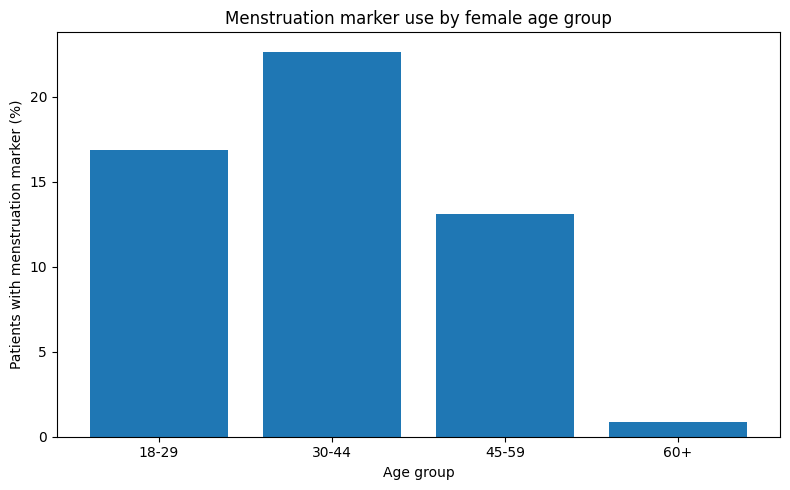

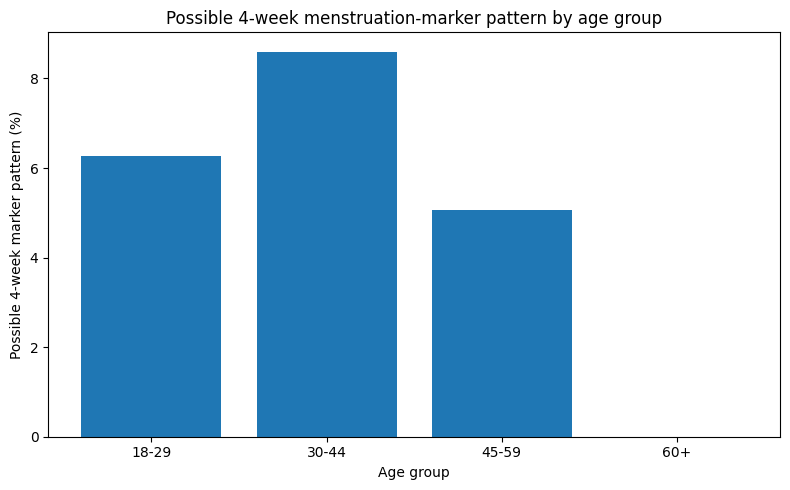

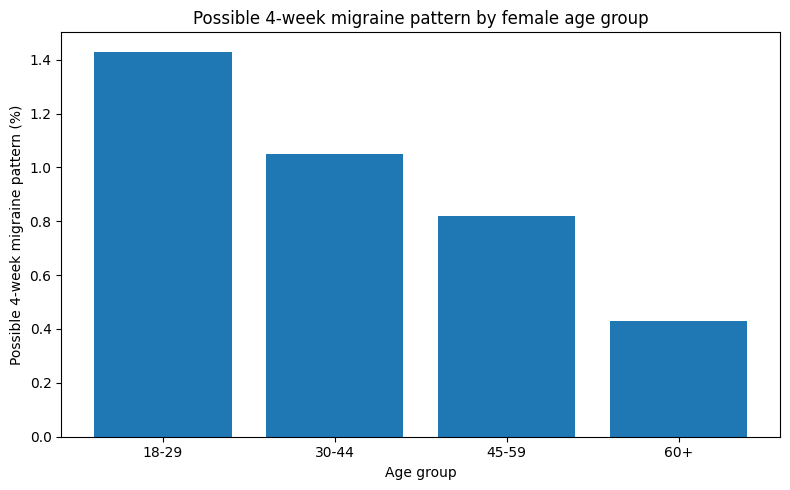

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    fq5_7_age_proxy_summary["age_group_proxy"],
    fq5_7_age_proxy_summary["percentage_with_menstruation_marker"]
)

plt.xlabel("Age group")
plt.ylabel("Patients with menstruation marker (%)")
plt.title("Menstruation marker use by female age group")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.bar(
    fq5_7_age_proxy_summary["age_group_proxy"],
    fq5_7_age_proxy_summary["percentage_possible_4_week_marker_pattern"]
)

plt.xlabel("Age group")
plt.ylabel("Possible 4-week marker pattern (%)")
plt.title("Possible 4-week menstruation-marker pattern by age group")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.bar(
    fq5_7_age_proxy_summary["age_group_proxy"],
    fq5_7_age_proxy_summary["percentage_possible_4_week_migraine_pattern"]
)

plt.xlabel("Age group")
plt.ylabel("Possible 4-week migraine pattern (%)")
plt.title("Possible 4-week migraine pattern by female age group")

plt.tight_layout()
plt.show()



In [83]:
# ------------------------------------------------------------
# Step 5.7 Cell 15: Chi-square driver analysis function
# ------------------------------------------------------------

def chi_square_driver_analysis(contingency_table, expected_table, analysis_label):
    observed_table = contingency_table.copy()

    contribution = (
        (observed_table - expected_table) ** 2
        / expected_table
    )

    contribution_percent = (
        contribution
        / contribution.values.sum()
        * 100
    )

    pearson_residuals = (
        (observed_table - expected_table)
        / np.sqrt(expected_table)
    )

    driver_rows = []

    for age_group in observed_table.index:
        for outcome_status in observed_table.columns:
            observed_value = observed_table.loc[age_group, outcome_status]
            expected_value = expected_table.loc[age_group, outcome_status]
            residual_value = pearson_residuals.loc[age_group, outcome_status]
            contribution_value = contribution.loc[age_group, outcome_status]
            contribution_percent_value = contribution_percent.loc[age_group, outcome_status]

            if residual_value > 0:
                direction = "observed higher than expected"
            elif residual_value < 0:
                direction = "observed lower than expected"
            else:
                direction = "observed equals expected"

            driver_rows.append({
                "analysis": analysis_label,
                "age_group": age_group,
                "outcome_status": outcome_status,
                "observed": observed_value,
                "expected_under_H0": expected_value,
                "difference_observed_minus_expected": observed_value - expected_value,
                "pearson_residual": residual_value,
                "direction": direction,
                "chi_square_contribution": contribution_value,
                "contribution_percent": contribution_percent_value
            })

    driver_table = pd.DataFrame(driver_rows)

    numeric_cols = [
        "expected_under_H0",
        "difference_observed_minus_expected",
        "pearson_residual",
        "chi_square_contribution",
        "contribution_percent"
    ]

    for col in numeric_cols:
        driver_table[col] = driver_table[col].round(3)

    driver_table = driver_table.sort_values(
        "contribution_percent",
        ascending=False
    )

    return driver_table

In [84]:
driver_marker_age = chi_square_driver_analysis(
    contingency_table=contingency_marker_age,
    expected_table=expected_marker_age,
    analysis_label="age_group_vs_menstruation_marker_use"
)

driver_marker_pattern_age = chi_square_driver_analysis(
    contingency_table=contingency_marker_pattern_age,
    expected_table=expected_marker_pattern_age,
    analysis_label="age_group_vs_possible_4_week_marker_pattern"
)

driver_migraine_pattern_age = chi_square_driver_analysis(
    contingency_table=contingency_migraine_pattern_age,
    expected_table=expected_migraine_pattern_age,
    analysis_label="age_group_vs_possible_4_week_migraine_pattern"
)

print("Drivers: age group vs menstruation marker use")
display(driver_marker_age)

print("\nDrivers: age group vs possible 4-week menstruation-marker pattern")
display(driver_marker_pattern_age)

print("\nDrivers: age group vs possible 4-week migraine pattern")
display(driver_migraine_pattern_age)

Drivers: age group vs menstruation marker use


,analysis,age_group,outcome_status,observed,expected_under_H0,difference_observed_minus_expected,pearson_residual,direction,chi_square_contribution,contribution_percent
7,age_group_vs_menstruation_marker_use,60+,outcome_true,14,282.176,-268.176,-15.965,observed lower than expected,254.870,32.800
3,age_group_vs_menstruation_marker_use,30-44,outcome_true,4172,3263.353,908.647,15.906,observed higher than expected,253.003,32.559
5,age_group_vs_menstruation_marker_use,45-59,outcome_true,1365,1842.910,-477.910,-11.133,observed lower than expected,123.933,15.949
6,age_group_vs_menstruation_marker_use,60+,outcome_false,1579,1310.824,268.176,7.407,observed higher than expected,54.865,7.061
2,age_group_vs_menstruation_marker_use,30-44,outcome_false,14251,15159.647,-908.647,-7.380,observed lower than expected,54.463,7.009
4,age_group_vs_menstruation_marker_use,45-59,outcome_false,9039,8561.090,477.910,5.165,observed higher than expected,26.679,3.433
1,age_group_vs_menstruation_marker_use,18-29,outcome_true,3313,3475.561,-162.561,-2.757,observed lower than expected,7.603,0.978
0,age_group_vs_menstruation_marker_use,18-29,outcome_false,16308,16145.439,162.561,1.279,observed higher than expected,1.637,0.211



Drivers: age group vs possible 4-week menstruation-marker pattern


,analysis,age_group,outcome_status,observed,expected_under_H0,difference_observed_minus_expected,pearson_residual,direction,chi_square_contribution,contribution_percent
3,age_group_vs_possible_4_week_marker_pattern,30-44,outcome_true,207,173.140,33.860,2.573,observed higher than expected,6.622,43.712
5,age_group_vs_possible_4_week_marker_pattern,45-59,outcome_true,42,59.679,-17.679,-2.288,observed lower than expected,5.237,34.570
1,age_group_vs_possible_4_week_marker_pattern,18-29,outcome_true,109,125.038,-16.038,-1.434,observed lower than expected,2.057,13.579
2,age_group_vs_possible_4_week_marker_pattern,30-44,outcome_false,2201,2234.860,-33.860,-0.716,observed lower than expected,0.513,3.386
4,age_group_vs_possible_4_week_marker_pattern,45-59,outcome_false,788,770.321,17.679,0.637,observed higher than expected,0.406,2.678
0,age_group_vs_possible_4_week_marker_pattern,18-29,outcome_false,1630,1613.962,16.038,0.399,observed higher than expected,0.159,1.052
7,age_group_vs_possible_4_week_marker_pattern,60+,outcome_true,0,0.144,-0.144,-0.379,observed lower than expected,0.144,0.949
6,age_group_vs_possible_4_week_marker_pattern,60+,outcome_false,2,1.856,0.144,0.106,observed higher than expected,0.011,0.074



Drivers: age group vs possible 4-week migraine pattern


,analysis,age_group,outcome_status,observed,expected_under_H0,difference_observed_minus_expected,pearson_residual,direction,chi_square_contribution,contribution_percent
1,age_group_vs_possible_4_week_migraine_pattern,18-29,outcome_true,126,97.710,28.290,2.862,observed higher than expected,8.191,48.647
5,age_group_vs_possible_4_week_migraine_pattern,45-59,outcome_true,49,66.008,-17.008,-2.093,observed lower than expected,4.382,26.029
7,age_group_vs_possible_4_week_migraine_pattern,60+,outcome_true,4,10.261,-6.261,-1.955,observed lower than expected,3.820,22.689
3,age_group_vs_possible_4_week_migraine_pattern,30-44,outcome_true,93,98.021,-5.021,-0.507,observed lower than expected,0.257,1.527
0,age_group_vs_possible_4_week_migraine_pattern,18-29,outcome_false,8692,8720.290,-28.290,-0.303,observed lower than expected,0.092,0.545
4,age_group_vs_possible_4_week_migraine_pattern,45-59,outcome_false,5908,5890.992,17.008,0.222,observed higher than expected,0.049,0.292
6,age_group_vs_possible_4_week_migraine_pattern,60+,outcome_false,922,915.739,6.261,0.207,observed higher than expected,0.043,0.254
2,age_group_vs_possible_4_week_migraine_pattern,30-44,outcome_false,8753,8747.979,5.021,0.054,observed higher than expected,0.003,0.017


In [85]:
# ------------------------------------------------------------
# Step 5.7 Cell 17: Kruskal-Wallis driver analysis for age groups
# ------------------------------------------------------------

def kruskal_driver_contribution_age(df, value_col, group_col, group_order, analysis_label):
    tmp = df[[value_col, group_col]].dropna().copy()
    tmp = tmp[tmp[group_col].isin(group_order)].copy()

    tmp["_rank"] = tmp[value_col].rank(method="average")

    n_total = len(tmp)
    overall_mean_rank = (n_total + 1) / 2
    overall_median = tmp[value_col].median()

    group_summary = (
        tmp
        .groupby(group_col, observed=True)
        .agg(
            n_patients=(value_col, "count"),
            median=(value_col, "median"),
            q1=(value_col, lambda x: x.quantile(0.25)),
            q3=(value_col, lambda x: x.quantile(0.75)),
            mean_rank=("_rank", "mean")
        )
        .reindex(group_order)
        .reset_index()
    )

    group_summary["iqr"] = group_summary["q3"] - group_summary["q1"]

    group_summary["median_difference_from_overall"] = (
        group_summary["median"] - overall_median
    )

    group_summary["mean_rank_difference_from_overall"] = (
        group_summary["mean_rank"] - overall_mean_rank
    )

    group_summary["contribution_raw"] = (
        group_summary["n_patients"]
        * group_summary["mean_rank_difference_from_overall"] ** 2
    )

    group_summary["contribution_percent"] = (
        group_summary["contribution_raw"]
        / group_summary["contribution_raw"].sum()
        * 100
    )

    group_summary["rank_direction"] = np.where(
        group_summary["mean_rank_difference_from_overall"] > 0,
        "higher than overall",
        "lower than overall"
    )

    group_summary["analysis"] = analysis_label

    result = group_summary[
        [
            "analysis",
            group_col,
            "n_patients",
            "median",
            "q1",
            "q3",
            "iqr",
            "median_difference_from_overall",
            "mean_rank",
            "mean_rank_difference_from_overall",
            "rank_direction",
            "contribution_percent"
        ]
    ].copy()

    numeric_cols = [
        "median",
        "q1",
        "q3",
        "iqr",
        "median_difference_from_overall",
        "mean_rank",
        "mean_rank_difference_from_overall",
        "contribution_percent"
    ]

    for col in numeric_cols:
        result[col] = result[col].round(3)

    return result.sort_values("contribution_percent", ascending=False)

In [86]:
driver_migraine_rate_age = kruskal_driver_contribution_age(
    df=female_age_proxy_base,
    value_col="migraine_attacks_per_30_days",
    group_col="age_group_proxy",
    group_order=AGE_GROUP_ORDER,
    analysis_label="age_group_vs_migraine_attacks_per_30_days"
)

display(driver_migraine_rate_age)

,analysis,age_group_proxy,n_patients,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
2,age_group_vs_migraine_attacks_per_30_days,45-59,10404,2.343,0.559,5.265,4.707,0.628,27378.414,2357.414,higher than overall,49.933
0,age_group_vs_migraine_attacks_per_30_days,18-29,19621,1.399,0.256,3.667,3.410,-0.316,23517.080,-1503.920,lower than overall,38.326
3,age_group_vs_migraine_attacks_per_30_days,60+,1593,2.615,0.577,5.714,5.137,0.901,27941.704,2920.704,higher than overall,11.736
1,age_group_vs_migraine_attacks_per_30_days,30-44,18423,1.714,0.323,4.375,4.053,0.000,25038.869,17.869,higher than overall,0.005
